## Exploratory Data Analysis

## Check GPU

In [18]:
import subprocess, warnings, platform, os, psutil, gc, time
warnings.filterwarnings('ignore')
try:
    r = subprocess.run(['nvidia-smi', '--query-gpu=name,memory.total',
                  '--format=csv,noheader'], capture_output=True, text=True)
    if r.returncode == 0:
        print("GPU:", r.stdout.strip())
    else:
        print("CPU ")
        
except FileNotFoundError:
    print("CPU ")

CPU 


In [19]:

print(f"Python  : {platform.python_version()}")
print(f"CPU     : {os.cpu_count()} logical cores")
print(f"RAM     : {psutil.virtual_memory().total/1e9  :.1f} GB total  |  "
      f"{psutil.virtual_memory().available/1e9 :.1f} GB free")

Python  : 3.12.12
CPU     : 4 logical cores
RAM     : 33.7 GB total  |  31.4 GB free


## Install dependencies
same versions as docker deployment version

In [20]:
%%capture
!pip install -q numpy==1.26.4 pandas==2.2.2 matplotlib seaborn scikit-learn==1.5.1 \
  scipy psutil --quiet


In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from tqdm.notebook import tqdm
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_classif
print(f"numpy   {np.__version__}")
print(f"pandas  {pd.__version__}")

numpy   1.26.4
pandas  2.2.2


In [22]:
# making dir for plots
working_dir= '/kaggle/working'
plots_dir = '/kaggle/working/plots_eda'
os.makedirs(plots_dir, exist_ok=True)

## Access Dataset

In [23]:
data_path="/kaggle/input/datasets/aryashah2k/nfuqnidsv2-network-intrusion-detection-dataset/NF-UQ-NIDS-v2.csv"
print(f"Dataset  : {os.path.basename(data_path)}")
print(f"Size     : {os.path.getsize(data_path)/1e9} GB")


Dataset  : NF-UQ-NIDS-v2.csv
Size     : 13.72933023 GB


## Chunked stratified sampling
The full dataset contains around 76 million NetFlow records which is too large to load 
into memory at once. To handle this, the data was read in chunks of 500,000 rows at a 
time. Within each chunk, duplicates were removed first, then 33% of rows were sampled 
from each attack class separately — this ensures that even rare attack types are 
represented in the final sample rather than being lost to random sampling. After all 
chunks were combined, a second deduplication pass removed any duplicates that appeared 
across different chunks. The result is a clean dataset of 22.8 million flows that 
preserves the original class distribution, fits comfortably in memory, and is 
representative enough for reliable EDA, preprocessing, and model training.

In [24]:
sample_rate=0.33
chunk_size=500000
random_seed=42
multi_class_target="Attack"  # multi-class attack name
binary_target="Label" # 0 = benign, 1 = attack

In [25]:
# Features names 
df_features = pd.read_csv(data_path, nrows=0)
all_features   = list(df_features.columns)
print(f"Features Names :\n{all_features}")
print(f"Number of Features:{len(all_features)}")

Features Names :
['IPV4_SRC_ADDR', 'L4_SRC_PORT', 'IPV4_DST_ADDR', 'L4_DST_PORT', 'PROTOCOL', 'L7_PROTO', 'IN_BYTES', 'IN_PKTS', 'OUT_BYTES', 'OUT_PKTS', 'TCP_FLAGS', 'CLIENT_TCP_FLAGS', 'SERVER_TCP_FLAGS', 'FLOW_DURATION_MILLISECONDS', 'DURATION_IN', 'DURATION_OUT', 'MIN_TTL', 'MAX_TTL', 'LONGEST_FLOW_PKT', 'SHORTEST_FLOW_PKT', 'MIN_IP_PKT_LEN', 'MAX_IP_PKT_LEN', 'SRC_TO_DST_SECOND_BYTES', 'DST_TO_SRC_SECOND_BYTES', 'RETRANSMITTED_IN_BYTES', 'RETRANSMITTED_IN_PKTS', 'RETRANSMITTED_OUT_BYTES', 'RETRANSMITTED_OUT_PKTS', 'SRC_TO_DST_AVG_THROUGHPUT', 'DST_TO_SRC_AVG_THROUGHPUT', 'NUM_PKTS_UP_TO_128_BYTES', 'NUM_PKTS_128_TO_256_BYTES', 'NUM_PKTS_256_TO_512_BYTES', 'NUM_PKTS_512_TO_1024_BYTES', 'NUM_PKTS_1024_TO_1514_BYTES', 'TCP_WIN_MAX_IN', 'TCP_WIN_MAX_OUT', 'ICMP_TYPE', 'ICMP_IPV4_TYPE', 'DNS_QUERY_ID', 'DNS_QUERY_TYPE', 'DNS_TTL_ANSWER', 'FTP_COMMAND_RET_CODE', 'Label', 'Attack', 'Dataset']
Number of Features:46


In [26]:
df_features.dtypes

IPV4_SRC_ADDR                  object
L4_SRC_PORT                    object
IPV4_DST_ADDR                  object
L4_DST_PORT                    object
PROTOCOL                       object
L7_PROTO                       object
IN_BYTES                       object
IN_PKTS                        object
OUT_BYTES                      object
OUT_PKTS                       object
TCP_FLAGS                      object
CLIENT_TCP_FLAGS               object
SERVER_TCP_FLAGS               object
FLOW_DURATION_MILLISECONDS     object
DURATION_IN                    object
DURATION_OUT                   object
MIN_TTL                        object
MAX_TTL                        object
LONGEST_FLOW_PKT               object
SHORTEST_FLOW_PKT              object
MIN_IP_PKT_LEN                 object
MAX_IP_PKT_LEN                 object
SRC_TO_DST_SECOND_BYTES        object
DST_TO_SRC_SECOND_BYTES        object
RETRANSMITTED_IN_BYTES         object
RETRANSMITTED_IN_PKTS          object
RETRANSMITTE

In [27]:
#drop non_predictive_features before reading the data
non_predictive_features = {'IPV4_SRC_ADDR', 'IPV4_DST_ADDR', 'Dataset'}
used_features=[c for c in all_features if c not in non_predictive_features ]
print(f"Features Names :\n{used_features}")
print(f"Number of Features:{len(used_features)}")
print(f"Dropped Features:{non_predictive_features} ")

Features Names :
['L4_SRC_PORT', 'L4_DST_PORT', 'PROTOCOL', 'L7_PROTO', 'IN_BYTES', 'IN_PKTS', 'OUT_BYTES', 'OUT_PKTS', 'TCP_FLAGS', 'CLIENT_TCP_FLAGS', 'SERVER_TCP_FLAGS', 'FLOW_DURATION_MILLISECONDS', 'DURATION_IN', 'DURATION_OUT', 'MIN_TTL', 'MAX_TTL', 'LONGEST_FLOW_PKT', 'SHORTEST_FLOW_PKT', 'MIN_IP_PKT_LEN', 'MAX_IP_PKT_LEN', 'SRC_TO_DST_SECOND_BYTES', 'DST_TO_SRC_SECOND_BYTES', 'RETRANSMITTED_IN_BYTES', 'RETRANSMITTED_IN_PKTS', 'RETRANSMITTED_OUT_BYTES', 'RETRANSMITTED_OUT_PKTS', 'SRC_TO_DST_AVG_THROUGHPUT', 'DST_TO_SRC_AVG_THROUGHPUT', 'NUM_PKTS_UP_TO_128_BYTES', 'NUM_PKTS_128_TO_256_BYTES', 'NUM_PKTS_256_TO_512_BYTES', 'NUM_PKTS_512_TO_1024_BYTES', 'NUM_PKTS_1024_TO_1514_BYTES', 'TCP_WIN_MAX_IN', 'TCP_WIN_MAX_OUT', 'ICMP_TYPE', 'ICMP_IPV4_TYPE', 'DNS_QUERY_ID', 'DNS_QUERY_TYPE', 'DNS_TTL_ANSWER', 'FTP_COMMAND_RET_CODE', 'Label', 'Attack']
Number of Features:43
Dropped Features:{'Dataset', 'IPV4_DST_ADDR', 'IPV4_SRC_ADDR'} 


In [28]:
#dtype map to cast every numerical feature column to float2 instead of pandas default float64 — this halves memory usage for numerical columns.
dtype_map={
    c: 'float32'
    for c in used_features
    if c not in (binary_target,multi_class_target) 
}


In [29]:
#Strips whitespace/newlines from attack name strings.
def parse_multi_class(x):
    return str(x).strip()

In [30]:
#converts binary label to int,Returns -1 for any malformed/missing.
def parse_binary_class(x):
    s=str(x).strip()
    if s in ('', 'nan', 'NaN', 'NULL'):
        return -1
    try:
        return int(float(s))
    except ValueError:
        return -1
    

In [31]:
converters={
    binary_target:parse_binary_class,
    multi_class_target:parse_multi_class
}

In [32]:
# Counting rows
with open(data_path, 'r') as f:
    total_rows = sum(1 for _ in f) - 1 
n_chunks = (total_rows // chunk_size) + 1
print(f"Estimated rows : {total_rows:,}")
print(f"Estimated chunks : {n_chunks:,}\n")

Estimated rows : 75,987,976
Estimated chunks : 152



In [33]:
csv_iter = pd.read_csv(
    data_path,
    chunksize=chunk_size,
    usecols=used_features,
    dtype=dtype_map,
    converters=converters,
    low_memory=False,
)

In [34]:
chunks = []
for chunk in tqdm(csv_iter,total=n_chunks, desc="Loading chunks"):
    chunk.drop_duplicates(inplace=True)
    sampled=(
        chunk.groupby(multi_class_target,group_keys=False)
        .apply(
            lambda x: x.sample(
                     n=max(1, int(len(x) * sample_rate)),
                     random_state=random_seed
                 )
        )
    )
    chunks.append(sampled)

df = pd.concat(chunks, ignore_index=True)
del chunks
gc.collect()
before = len(df) 
print(f"Before dropping duplicates : {before:,}")
df.drop_duplicates(keep='first', inplace=True)
df.reset_index(drop=True, inplace=True)
print(f"After dropping duplicates  : {len(df):,}")
print(f"Dropped      : {before - len(df):,}")    

Loading chunks:   0%|          | 0/152 [00:00<?, ?it/s]

Before dropping duplicates : 24,922,530
After dropping duplicates  : 22,822,550
Dropped      : 2,099,980


## Information About The Data 

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22822550 entries, 0 to 22822549
Data columns (total 43 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   L4_SRC_PORT                  float32
 1   L4_DST_PORT                  float32
 2   PROTOCOL                     float32
 3   L7_PROTO                     float32
 4   IN_BYTES                     float32
 5   IN_PKTS                      float32
 6   OUT_BYTES                    float32
 7   OUT_PKTS                     float32
 8   TCP_FLAGS                    float32
 9   CLIENT_TCP_FLAGS             float32
 10  SERVER_TCP_FLAGS             float32
 11  FLOW_DURATION_MILLISECONDS   float32
 12  DURATION_IN                  float32
 13  DURATION_OUT                 float32
 14  MIN_TTL                      float32
 15  MAX_TTL                      float32
 16  LONGEST_FLOW_PKT             float32
 17  SHORTEST_FLOW_PKT            float32
 18  MIN_IP_PKT_LEN               float32
 19

In [36]:
df.describe()

,L4_SRC_PORT,L4_DST_PORT,PROTOCOL,L7_PROTO,IN_BYTES,IN_PKTS,OUT_BYTES,OUT_PKTS,TCP_FLAGS,CLIENT_TCP_FLAGS,...,NUM_PKTS_1024_TO_1514_BYTES,TCP_WIN_MAX_IN,TCP_WIN_MAX_OUT,ICMP_TYPE,ICMP_IPV4_TYPE,DNS_QUERY_ID,DNS_QUERY_TYPE,DNS_TTL_ANSWER,FTP_COMMAND_RET_CODE,Label
count,2.282255e+07,2.282255e+07,2.282255e+07,2.282255e+07,2.282255e+07,2.282255e+07,2.282255e+07,2.282255e+07,2.282255e+07,2.282255e+07,...,2.282255e+07,2.282255e+07,2.282255e+07,2.282255e+07,2.282255e+07,2.282255e+07,2.282255e+07,2.282255e+07,2.282255e+07,2.282255e+07
mean,4.040017e+04,3.423193e+03,1.035305e+01,5.262866e+01,1.127548e+03,1.047397e+01,3.434512e+03,5.123058e+00,2.445519e+01,2.250869e+01,...,2.244213e+00,6.303859e+03,8.796522e+03,4.005724e+03,1.564733e+01,4.910274e+03,1.490176e+00,2.137221e+04,1.576513e+00,6.728529e-01
std,1.821158e+04,1.054291e+04,5.280093e+00,7.115986e+01,1.145079e+05,6.486602e+02,2.860032e+05,2.401691e+02,5.647625e+01,5.644267e+01,...,1.965801e+02,1.289638e+04,1.722222e+04,1.142162e+04,4.461566e+01,1.314133e+04,1.682990e+01,9.299521e+06,2.082314e+01,4.691715e-01
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.705700e+04,8.000000e+01,6.000000e+00,0.000000e+00,5.600000e+01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,4.583700e+04,8.000000e+01,6.000000e+00,7.000000e+00,1.160000e+02,2.000000e+00,0.000000e+00,0.000000e+00,2.000000e+00,2.000000e+00,...,0.000000e+00,5.120000e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
75%,5.520700e+04,4.430000e+02,1.700000e+01,9.122000e+01,3.200000e+02,3.000000e+00,1.640000e+02,2.000000e+00,2.200000e+01,6.000000e+00,...,0.000000e+00,4.096000e+03,5.792000e+03,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
max,6.553500e+04,6.553500e+04,2.550000e+02,2.480000e+02,2.717849e+08,4.692810e+05,2.643994e+08,3.672180e+05,2.230000e+02,2.230000e+02,...,1.807530e+05,6.553500e+04,6.553500e+04,6.528600e+04,2.550000e+02,6.553500e+04,3.276900e+04,4.294916e+09,5.530000e+02,1.000000e+00


In [37]:
df.describe(include="object")

,Attack
count,22822550
unique,21
top,Benign
freq,7466331


In [38]:
# see if there is any corrupted target
bad_binary = (df[binary_target] == -1).sum()
bad_label  = (df[multi_class_target] == '').sum()
print(bad_binary)
print(bad_label)

0
0


In [39]:
print(f"Shape:{df.shape[0]:,}rows * {df.shape[1]:,}columns")
print(f"Attack: {(df[binary_target]==1).sum():,} | ({(df[binary_target]==1).mean()*100:.2f}%)")
print(f"Benign: {(df[binary_target]==0).sum():,} | ({(df[binary_target]==0).mean()*100:.2f}%)")
binary_counts=df[binary_target].value_counts().sort_index()
print(f"Imbalance Ratio (Attack:Benign):{binary_counts[1]/binary_counts[0]:.2f}")

Shape:22,822,550rows * 43columns
Attack: 15,356,219 | (67.29%)
Benign: 7,466,331 | (32.71%)
Imbalance Ratio (Attack:Benign):2.06


In [40]:
#Multiclass distribution
attack_dist = (
    df[multi_class_target]
    .value_counts()
    .rename_axis('Attack Type')
    .reset_index(name='Count')
)
attack_dist['Pct %'] = (attack_dist['Count'] / len(df) * 100).round(3)
print(attack_dist.to_string(index=False))
print(f"\nUnique attack types : {df[multi_class_target].nunique()}")

   Attack Type   Count  Pct %
        Benign 7466331 32.715
          DDoS 6554772 28.721
           DoS 5440618 23.839
      scanning 1009069  4.421
Reconnaissance  831823  3.645
           xss  809511  3.547
      password  357848  1.568
     injection  222959  0.977
   Brute Force   40827  0.179
 Infilteration   38231  0.168
           Bot   19598  0.086
      Exploits    9919  0.043
       Fuzzers    6918  0.030
      Backdoor    5826  0.026
       Generic    3223  0.014
          mitm    2477  0.011
    ransomware    1035  0.005
         Theft     704  0.003
     Shellcode     381  0.002
      Analysis     377  0.002
         Worms     103  0.000

Unique attack types : 21


In [41]:
#rare classes
rare = attack_dist[attack_dist['Count'] < 1000]
if len(rare):
    print(f"\n Rare classes (< 1000 samples) ")
    print(rare.to_string(index=False))
else:
    print("\nNo Rare classes found")


 Rare classes (< 1000 samples) 
Attack Type  Count  Pct %
      Theft    704  0.003
  Shellcode    381  0.002
   Analysis    377  0.002
      Worms    103  0.000


## Dataset visualization

## binary class distribution(bar and pie chart)

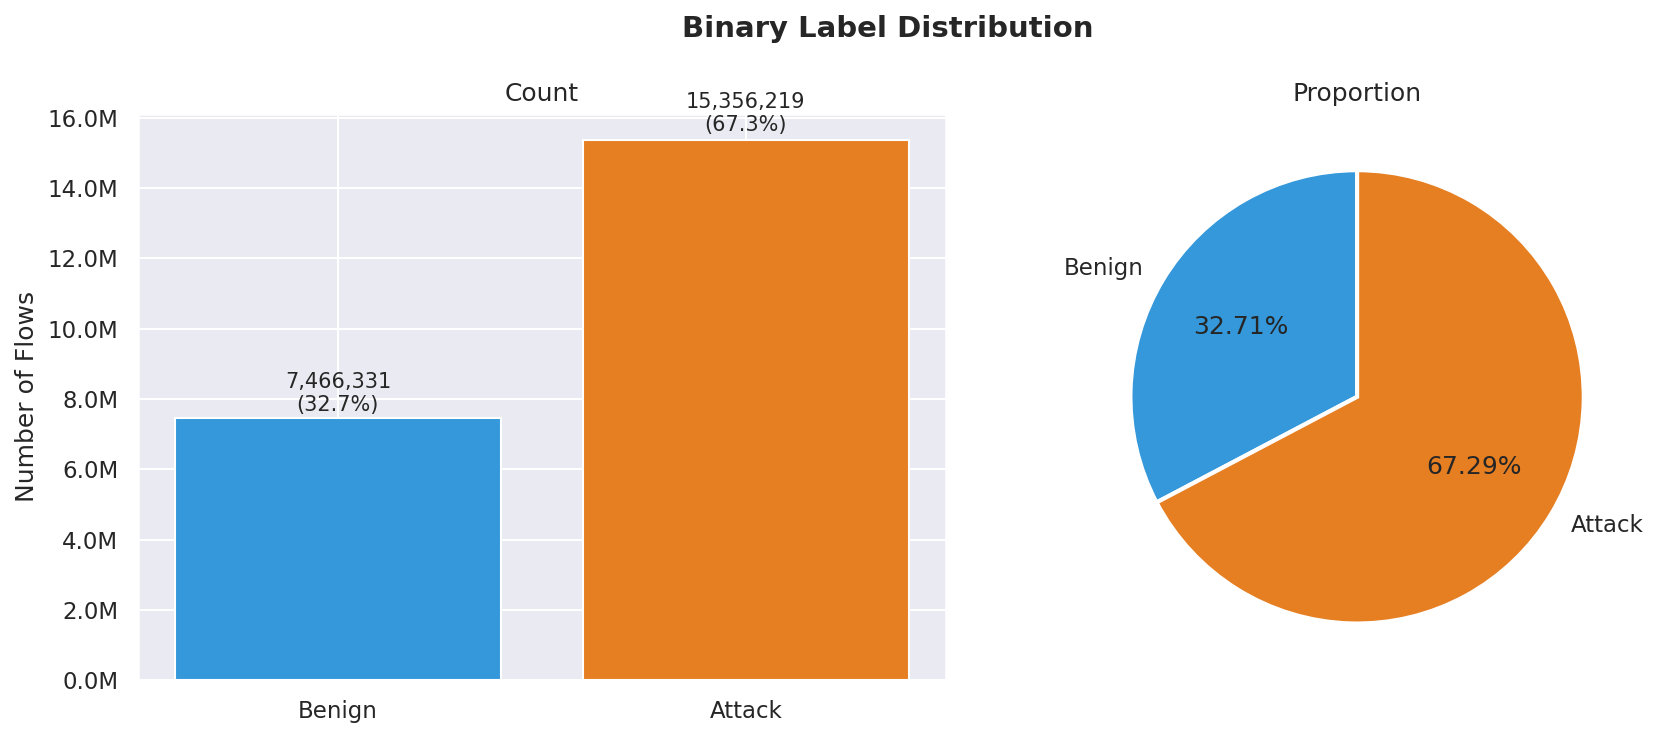

In [42]:
sns.set_theme(style='darkgrid', palette='muted')
fig,axes=plt.subplots(1,2,figsize=(12, 5),dpi=150)
fig.suptitle('Binary Label Distribution', fontsize=14, fontweight='bold')

#Bar chart 
axes[0].bar(["Benign","Attack"],binary_counts.values,color=['#3498db', '#e67e22'])
axes[0].set_title('Count')
axes[0].set_ylabel('Number of Flows')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
for i, v in enumerate(binary_counts.values):
    axes[0].text(i, v * 1.01, f'{v:,}\n({v/len(df)*100:.1f}%)',
                 ha='center', va='bottom', fontsize=10)
    
# Pie chart
axes[1].pie(binary_counts.values,labels=["Benign","Attack"], autopct='%1.2f%%',colors= ['#3498db', '#e67e22'],startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proportion')
plt.tight_layout()
plt.savefig(f'{plots_dir}/target_binary.png', dpi=150, bbox_inches='tight')
plt.show()

In [43]:
list_of_attacks=attack_dist["Attack Type"].values.tolist()
list_of_attacks_counts=attack_dist["Count"].values.tolist()

## multi class distribution(bar chart)

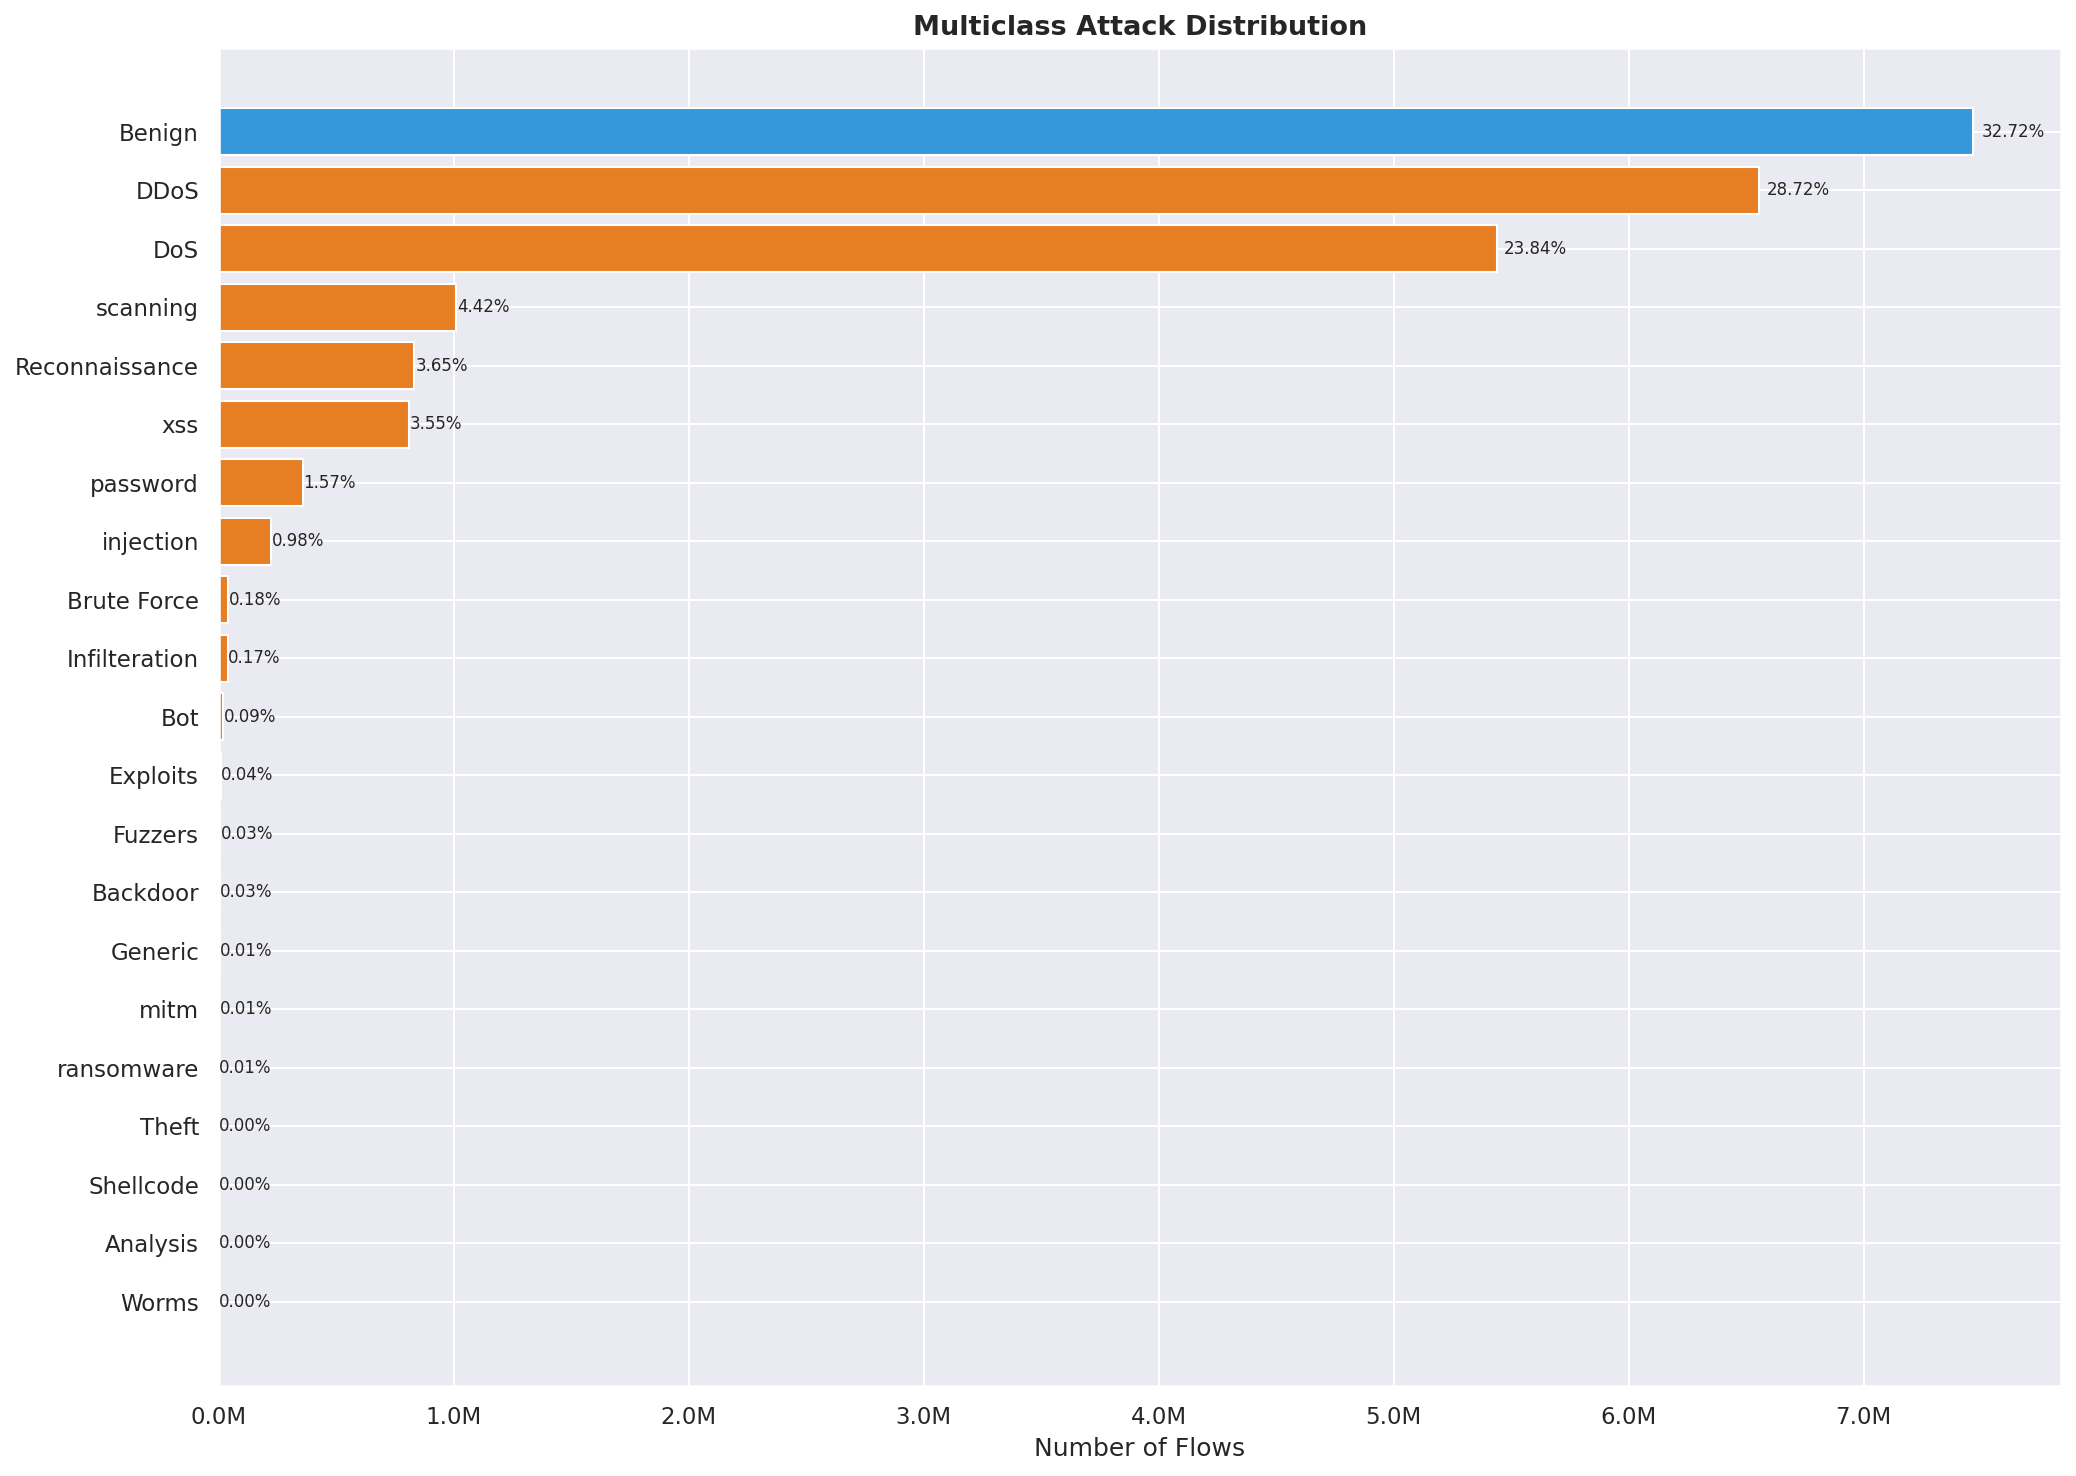

In [44]:
fig, ax = plt.subplots(figsize=(14, 10), dpi=150)
# bar chart
bars = ax.barh(attack_dist['Attack Type'], attack_dist['Count'],
              edgecolor='white')
ax.barh(list_of_attacks,list_of_attacks_counts,color=[ '#3498db' if x == "Benign" else '#e67e22'  for x in list_of_attacks])
ax.set_xlabel('Number of Flows')
ax.set_title('Multiclass Attack Distribution',fontsize=13, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax.invert_yaxis()
for bar, pct in zip(bars, attack_dist['Pct %']):
    ax.text(bar.get_width() * 1.005, bar.get_y() + bar.get_height() / 2,
            f'{pct:.2f}%', va='center', fontsize=8)

plt.tight_layout()
plt.savefig(f'{plots_dir}/multiclass_target.png', dpi=150, bbox_inches='tight')
plt.show()

In [45]:
#check for inf values 
print(np.isinf(df.select_dtypes(include=np.number)).sum())
print(f"total nuumber of inf values:{np.isinf(df.select_dtypes(include=np.number)).sum().sum()}")

L4_SRC_PORT                     0
L4_DST_PORT                     0
PROTOCOL                        0
L7_PROTO                        0
IN_BYTES                        0
IN_PKTS                         0
OUT_BYTES                       0
OUT_PKTS                        0
TCP_FLAGS                       0
CLIENT_TCP_FLAGS                0
SERVER_TCP_FLAGS                0
FLOW_DURATION_MILLISECONDS      0
DURATION_IN                     0
DURATION_OUT                    0
MIN_TTL                         0
MAX_TTL                         0
LONGEST_FLOW_PKT                0
SHORTEST_FLOW_PKT               0
MIN_IP_PKT_LEN                  0
MAX_IP_PKT_LEN                  0
SRC_TO_DST_SECOND_BYTES        94
DST_TO_SRC_SECOND_BYTES        31
RETRANSMITTED_IN_BYTES          0
RETRANSMITTED_IN_PKTS           0
RETRANSMITTED_OUT_BYTES         0
RETRANSMITTED_OUT_PKTS          0
SRC_TO_DST_AVG_THROUGHPUT       0
DST_TO_SRC_AVG_THROUGHPUT       0
NUM_PKTS_UP_TO_128_BYTES        0
NUM_PKTS_128_T

In [46]:
print("inf values percentage\n")
(np.isinf(df.select_dtypes(include=np.number)).sum()/len(df))*100

inf values percentage



L4_SRC_PORT                    0.000000
L4_DST_PORT                    0.000000
PROTOCOL                       0.000000
L7_PROTO                       0.000000
IN_BYTES                       0.000000
IN_PKTS                        0.000000
OUT_BYTES                      0.000000
OUT_PKTS                       0.000000
TCP_FLAGS                      0.000000
CLIENT_TCP_FLAGS               0.000000
SERVER_TCP_FLAGS               0.000000
FLOW_DURATION_MILLISECONDS     0.000000
DURATION_IN                    0.000000
DURATION_OUT                   0.000000
MIN_TTL                        0.000000
MAX_TTL                        0.000000
LONGEST_FLOW_PKT               0.000000
SHORTEST_FLOW_PKT              0.000000
MIN_IP_PKT_LEN                 0.000000
MAX_IP_PKT_LEN                 0.000000
SRC_TO_DST_SECOND_BYTES        0.000412
DST_TO_SRC_SECOND_BYTES        0.000136
RETRANSMITTED_IN_BYTES         0.000000
RETRANSMITTED_IN_PKTS          0.000000
RETRANSMITTED_OUT_BYTES        0.000000


In [47]:
#replace inf with nan
df.replace([np.inf,-np.inf],np.nan,inplace=True)
print(f"Inf values after replacement : {np.isinf(df.select_dtypes(include=np.number)).sum().sum()}")
print(f"NaN values after replacement : {df.isnull().sum().sum()}")
print(f"NaN values in each feature:\n{df.isnull().sum()}")

Inf values after replacement : 0
NaN values after replacement : 125
NaN values in each feature:
L4_SRC_PORT                     0
L4_DST_PORT                     0
PROTOCOL                        0
L7_PROTO                        0
IN_BYTES                        0
IN_PKTS                         0
OUT_BYTES                       0
OUT_PKTS                        0
TCP_FLAGS                       0
CLIENT_TCP_FLAGS                0
SERVER_TCP_FLAGS                0
FLOW_DURATION_MILLISECONDS      0
DURATION_IN                     0
DURATION_OUT                    0
MIN_TTL                         0
MAX_TTL                         0
LONGEST_FLOW_PKT                0
SHORTEST_FLOW_PKT               0
MIN_IP_PKT_LEN                  0
MAX_IP_PKT_LEN                  0
SRC_TO_DST_SECOND_BYTES        94
DST_TO_SRC_SECOND_BYTES        31
RETRANSMITTED_IN_BYTES          0
RETRANSMITTED_IN_PKTS           0
RETRANSMITTED_OUT_BYTES         0
RETRANSMITTED_OUT_PKTS          0
SRC_TO_DST_AVG_THROU

## Missing values

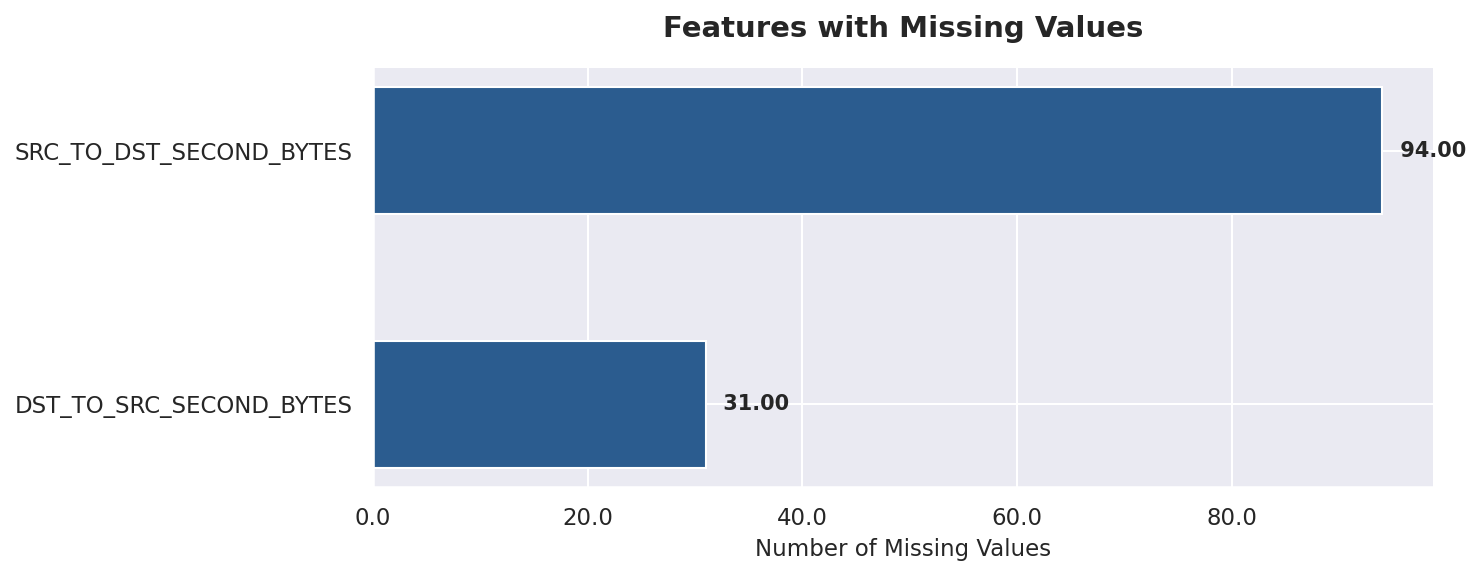

In [48]:
missing_counts = df.isnull().sum()
missing_only = missing_counts[missing_counts > 0].sort_values(ascending=True)


fig, ax = plt.subplots(figsize=(10, 4), dpi=150)  # Reduced height for fewer rows


bars = ax.barh(missing_only.index, missing_only, color='#2b5c8f', height=0.5)

ax.set_title('Features with Missing Values', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Number of Missing Values', fontsize=11)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}'))


for bar in bars:
    width = bar.get_width()
    ax.annotate(f' {width:.2f}',
                xy=(width, bar.get_y() + bar.get_height() / 2),
                xytext=(5, 0),  # 5 points horizontal offset
                textcoords="offset points",
                ha='left', va='center', fontsize=10, fontweight='bold')


for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig(f'{plots_dir}/Missing_values.png', dpi=150, bbox_inches='tight')
plt.show()


In [49]:
#check for duplicated rows-->had been removed after loading
df.duplicated().sum()


0

In [50]:
#check features
feature_cols = [c for c in df.columns if c not in (binary_target,multi_class_target)]

numerical_cols    = df[feature_cols].select_dtypes(include=np.number).columns.tolist()
categorical_cols  = df[feature_cols].select_dtypes(include=['object','category']).columns.tolist()

print(f"Total features      : {len(feature_cols)}")
print(f"Numerical           : {len(numerical_cols)}")
print(f"Categorical         : {len(categorical_cols)}")
print(f"\nNumerical columns:\n{numerical_cols}")
print(f"\nCategorical columns:\n{categorical_cols}")

Total features      : 41
Numerical           : 41
Categorical         : 0

Numerical columns:
['L4_SRC_PORT', 'L4_DST_PORT', 'PROTOCOL', 'L7_PROTO', 'IN_BYTES', 'IN_PKTS', 'OUT_BYTES', 'OUT_PKTS', 'TCP_FLAGS', 'CLIENT_TCP_FLAGS', 'SERVER_TCP_FLAGS', 'FLOW_DURATION_MILLISECONDS', 'DURATION_IN', 'DURATION_OUT', 'MIN_TTL', 'MAX_TTL', 'LONGEST_FLOW_PKT', 'SHORTEST_FLOW_PKT', 'MIN_IP_PKT_LEN', 'MAX_IP_PKT_LEN', 'SRC_TO_DST_SECOND_BYTES', 'DST_TO_SRC_SECOND_BYTES', 'RETRANSMITTED_IN_BYTES', 'RETRANSMITTED_IN_PKTS', 'RETRANSMITTED_OUT_BYTES', 'RETRANSMITTED_OUT_PKTS', 'SRC_TO_DST_AVG_THROUGHPUT', 'DST_TO_SRC_AVG_THROUGHPUT', 'NUM_PKTS_UP_TO_128_BYTES', 'NUM_PKTS_128_TO_256_BYTES', 'NUM_PKTS_256_TO_512_BYTES', 'NUM_PKTS_512_TO_1024_BYTES', 'NUM_PKTS_1024_TO_1514_BYTES', 'TCP_WIN_MAX_IN', 'TCP_WIN_MAX_OUT', 'ICMP_TYPE', 'ICMP_IPV4_TYPE', 'DNS_QUERY_ID', 'DNS_QUERY_TYPE', 'DNS_TTL_ANSWER', 'FTP_COMMAND_RET_CODE']

Categorical columns:
[]


In [51]:
#check for any constant features
constant_cols = [c for c in numerical_cols if df[c].nunique() <= 1]
print(f"Constant columns : {len(constant_cols)}")

Constant columns : 0


In [52]:
df[numerical_cols].skew()

L4_SRC_PORT                      -0.663067
L4_DST_PORT                       3.900433
PROTOCOL                          1.971614
L7_PROTO                          1.061240
IN_BYTES                        989.787476
IN_PKTS                         216.184006
OUT_BYTES                       380.335632
OUT_PKTS                        494.105286
TCP_FLAGS                         2.935423
CLIENT_TCP_FLAGS                  2.975999
SERVER_TCP_FLAGS                  3.637751
FLOW_DURATION_MILLISECONDS       -0.214359
DURATION_IN                      49.391460
DURATION_OUT                    148.286148
MIN_TTL                           0.184499
MAX_TTL                           0.187188
LONGEST_FLOW_PKT                  3.868917
SHORTEST_FLOW_PKT                 5.166595
MIN_IP_PKT_LEN                    0.587456
MAX_IP_PKT_LEN                    3.868917
SRC_TO_DST_SECOND_BYTES                NaN
DST_TO_SRC_SECOND_BYTES                NaN
RETRANSMITTED_IN_BYTES         1126.810547
RETRANSMITT

In [53]:
df[numerical_cols].kurt()

L4_SRC_PORT                   -7.410868e-01
L4_DST_PORT                    1.473192e+01
PROTOCOL                       5.261924e+01
L7_PROTO                      -7.785271e-01
IN_BYTES                       1.758825e+06
IN_PKTS                        6.999726e+04
OUT_BYTES                      1.971275e+05
OUT_PKTS                       4.264597e+05
TCP_FLAGS                      6.971808e+00
CLIENT_TCP_FLAGS               7.121675e+00
SERVER_TCP_FLAGS               2.255277e+01
FLOW_DURATION_MILLISECONDS    -1.954050e+00
DURATION_IN                    5.642508e+03
DURATION_OUT                   1.203322e+05
MIN_TTL                        3.148451e-01
MAX_TTL                        3.384697e-01
LONGEST_FLOW_PKT               2.394724e+02
SHORTEST_FLOW_PKT              1.232945e+02
MIN_IP_PKT_LEN                 8.180104e-01
MAX_IP_PKT_LEN                 2.394724e+02
SRC_TO_DST_SECOND_BYTES                 NaN
DST_TO_SRC_SECOND_BYTES                 NaN
RETRANSMITTED_IN_BYTES         1

In [54]:
#fill NaN values for skewness calculatiom
df_num = df[numerical_cols].apply(pd.to_numeric, errors='coerce')
fill_values = df_num.median().fillna(0)
df_imputed= df_num.fillna(fill_values)
skew_kurt=pd.DataFrame(
    {
    'Skewness' :df_imputed.skew().fillna(0.0),
    'Kurtosis' :df_imputed.kurt().fillna(0.0)
    }
).round(3).sort_values('Skewness', ascending=False)
skew_kurt['Needs Log Transform'] = skew_kurt['Skewness'].abs() > 1.0

In [55]:
skew_kurt

,Skewness,Kurtosis,Needs Log Transform
DNS_QUERY_TYPE,1286.027954,2.489522e+06,True
NUM_PKTS_128_TO_256_BYTES,1266.157959,2.987480e+06,True
RETRANSMITTED_IN_BYTES,1126.810059,1.711987e+06,True
IN_BYTES,989.788025,1.758825e+06,True
RETRANSMITTED_IN_PKTS,867.151978,8.581772e+05,True
NUM_PKTS_512_TO_1024_BYTES,547.062988,3.342221e+05,True
NUM_PKTS_256_TO_512_BYTES,526.346985,3.481898e+05,True
OUT_PKTS,494.105011,4.264597e+05,True
DNS_TTL_ANSWER,459.878998,2.119521e+05,True
OUT_BYTES,380.335999,1.971275e+05,True


In [56]:
print(f"\nFeatures needing log transform : {skew_kurt['Needs Log Transform'].sum()}")


Features needing log transform : 34


## Skewness & Kurtosis per Feature

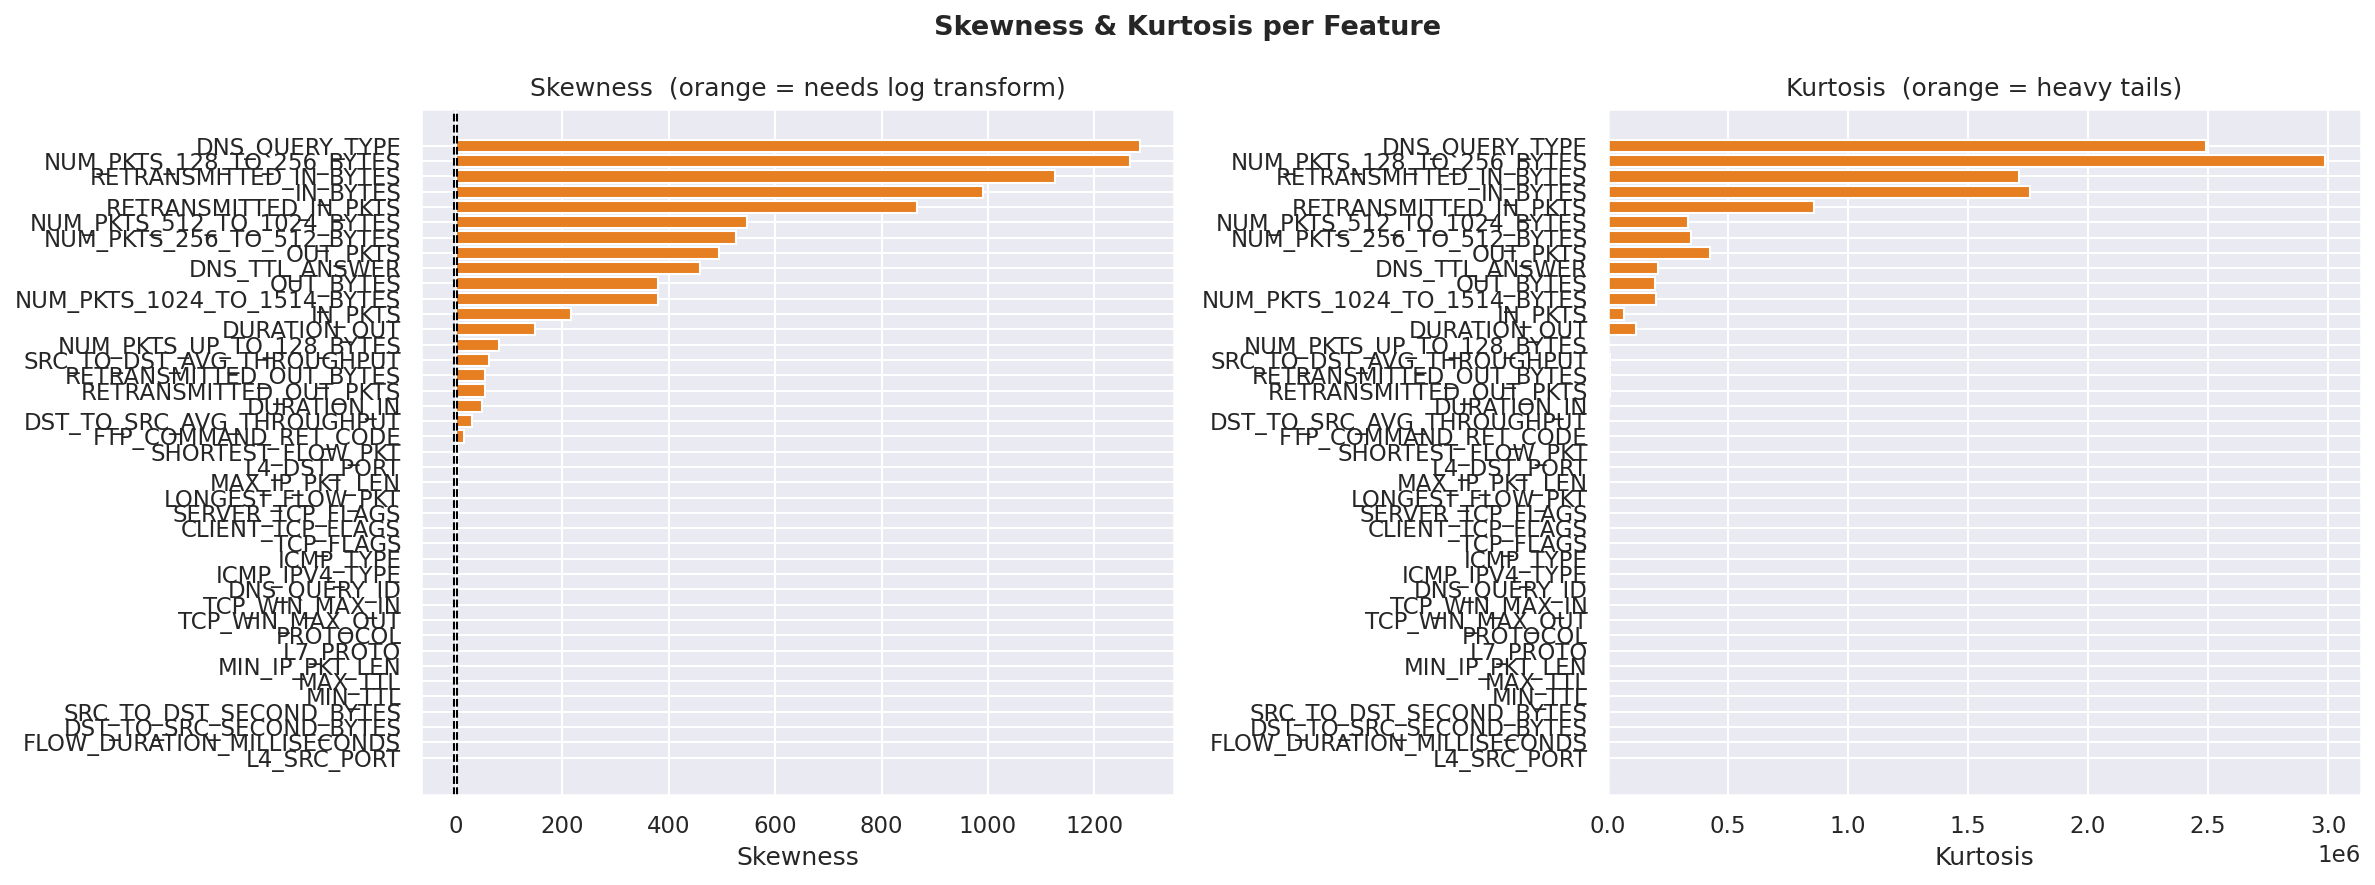

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), dpi=150)
fig.suptitle('Skewness & Kurtosis per Feature', fontsize=13, fontweight='bold')

# skewness
colors_skew = ['#e67e22' if abs(v) > 1.0 else '#3498db' 
               for v in skew_kurt['Skewness']]
axes[0].barh(skew_kurt.index, skew_kurt['Skewness'],
             color=colors_skew, edgecolor='white')
axes[0].axvline( 3, color='black', linestyle='--', linewidth=1)
axes[0].axvline(-3, color='black', linestyle='--', linewidth=1)
axes[0].set_title('Skewness  (orange = needs log transform)')
axes[0].set_xlabel('Skewness')
axes[0].invert_yaxis()

# kurtosis
colors_kurt = ['#e67e22' if abs(v) > 10 else '#3498db' 
               for v in skew_kurt['Kurtosis']]
axes[1].barh(skew_kurt.index, skew_kurt['Kurtosis'],
             color=colors_kurt, edgecolor='white')
axes[1].axvline( 10, color='black', linestyle='--', linewidth=1)
axes[1].axvline(-10, color='black', linestyle='--', linewidth=1)
axes[1].set_title('Kurtosis  (orange = heavy tails)')
axes[1].set_xlabel('Kurtosis')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(f'{plots_dir}/skewness_kurtosis.png', dpi=150, bbox_inches='tight')
plt.show()

## Feature Distributions (Histograms)
# original histograms

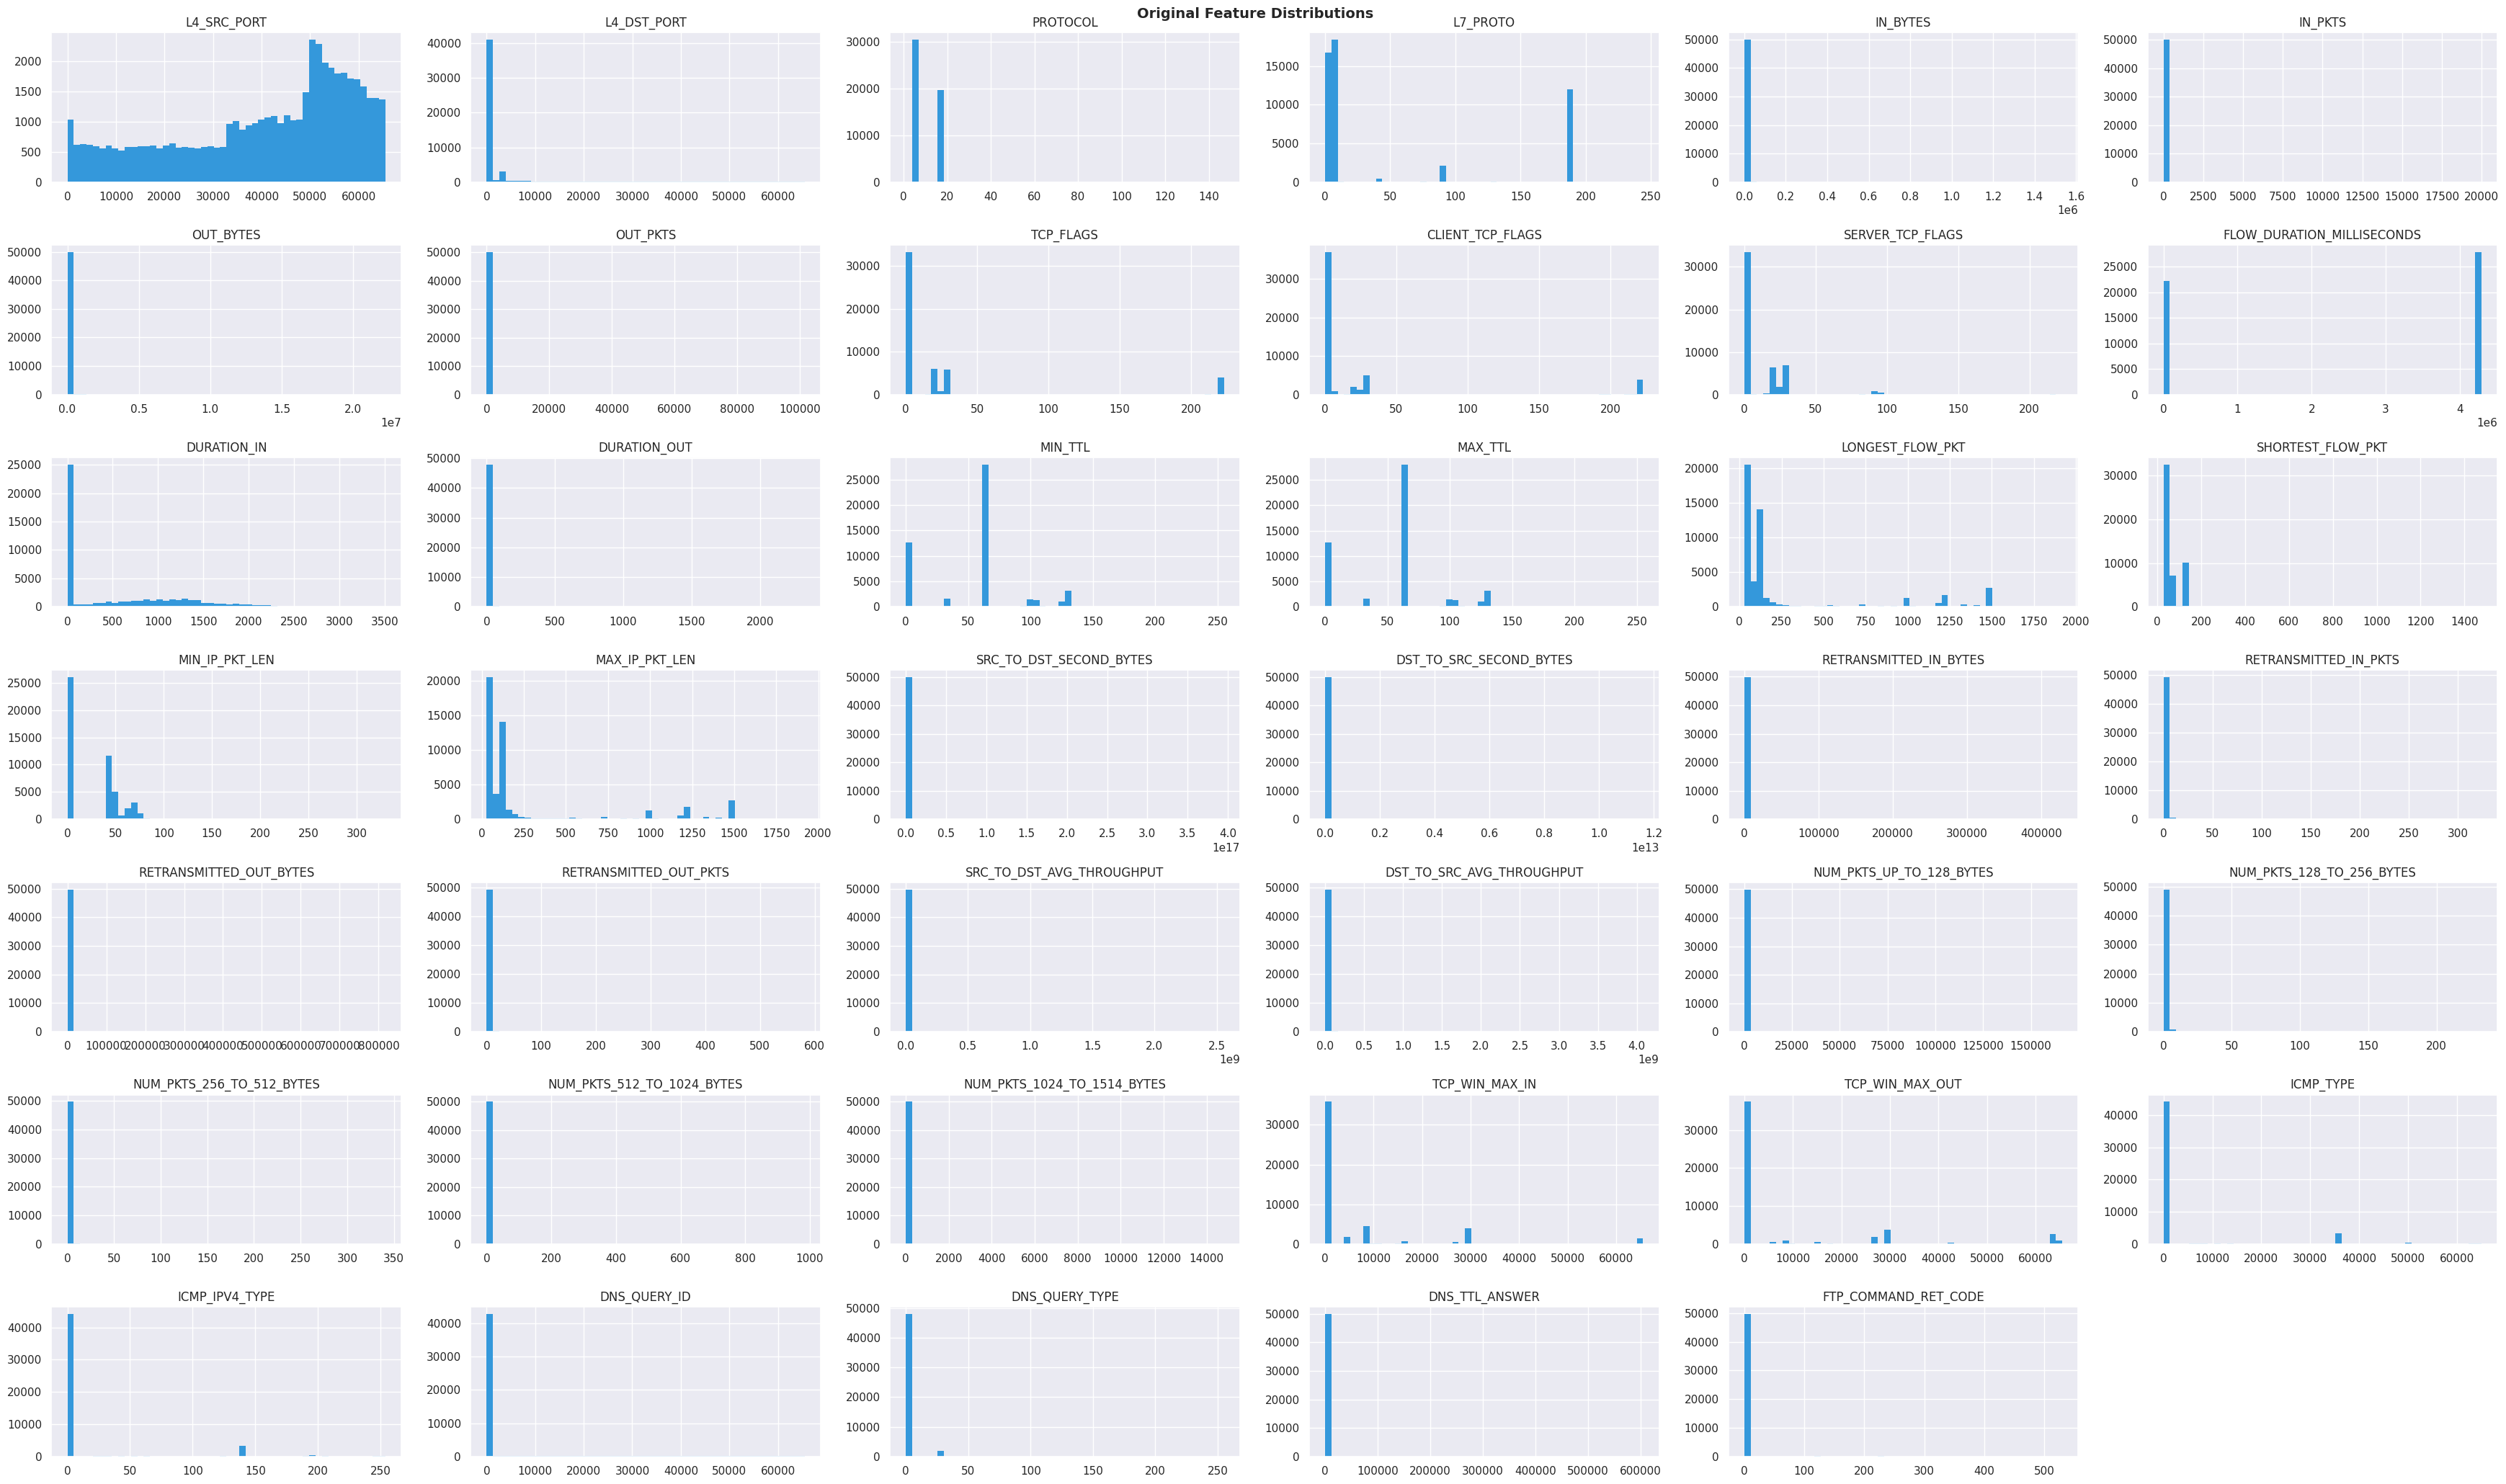

In [58]:
# Sample the data
n_cols = 7
n_rows = int(np.ceil(len(numerical_cols) / n_cols))
plot_df = df[numerical_cols].sample(n=50_000, random_state=42)
plot_df.hist(bins=50, figsize=(n_cols * 5, n_rows * 3.5), color='#3498db', edgecolor='none')
plt.suptitle('Original Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{plots_dir}/features_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


## Feature Distributions (Histograms) 
# (log1p) for features with severe skewness

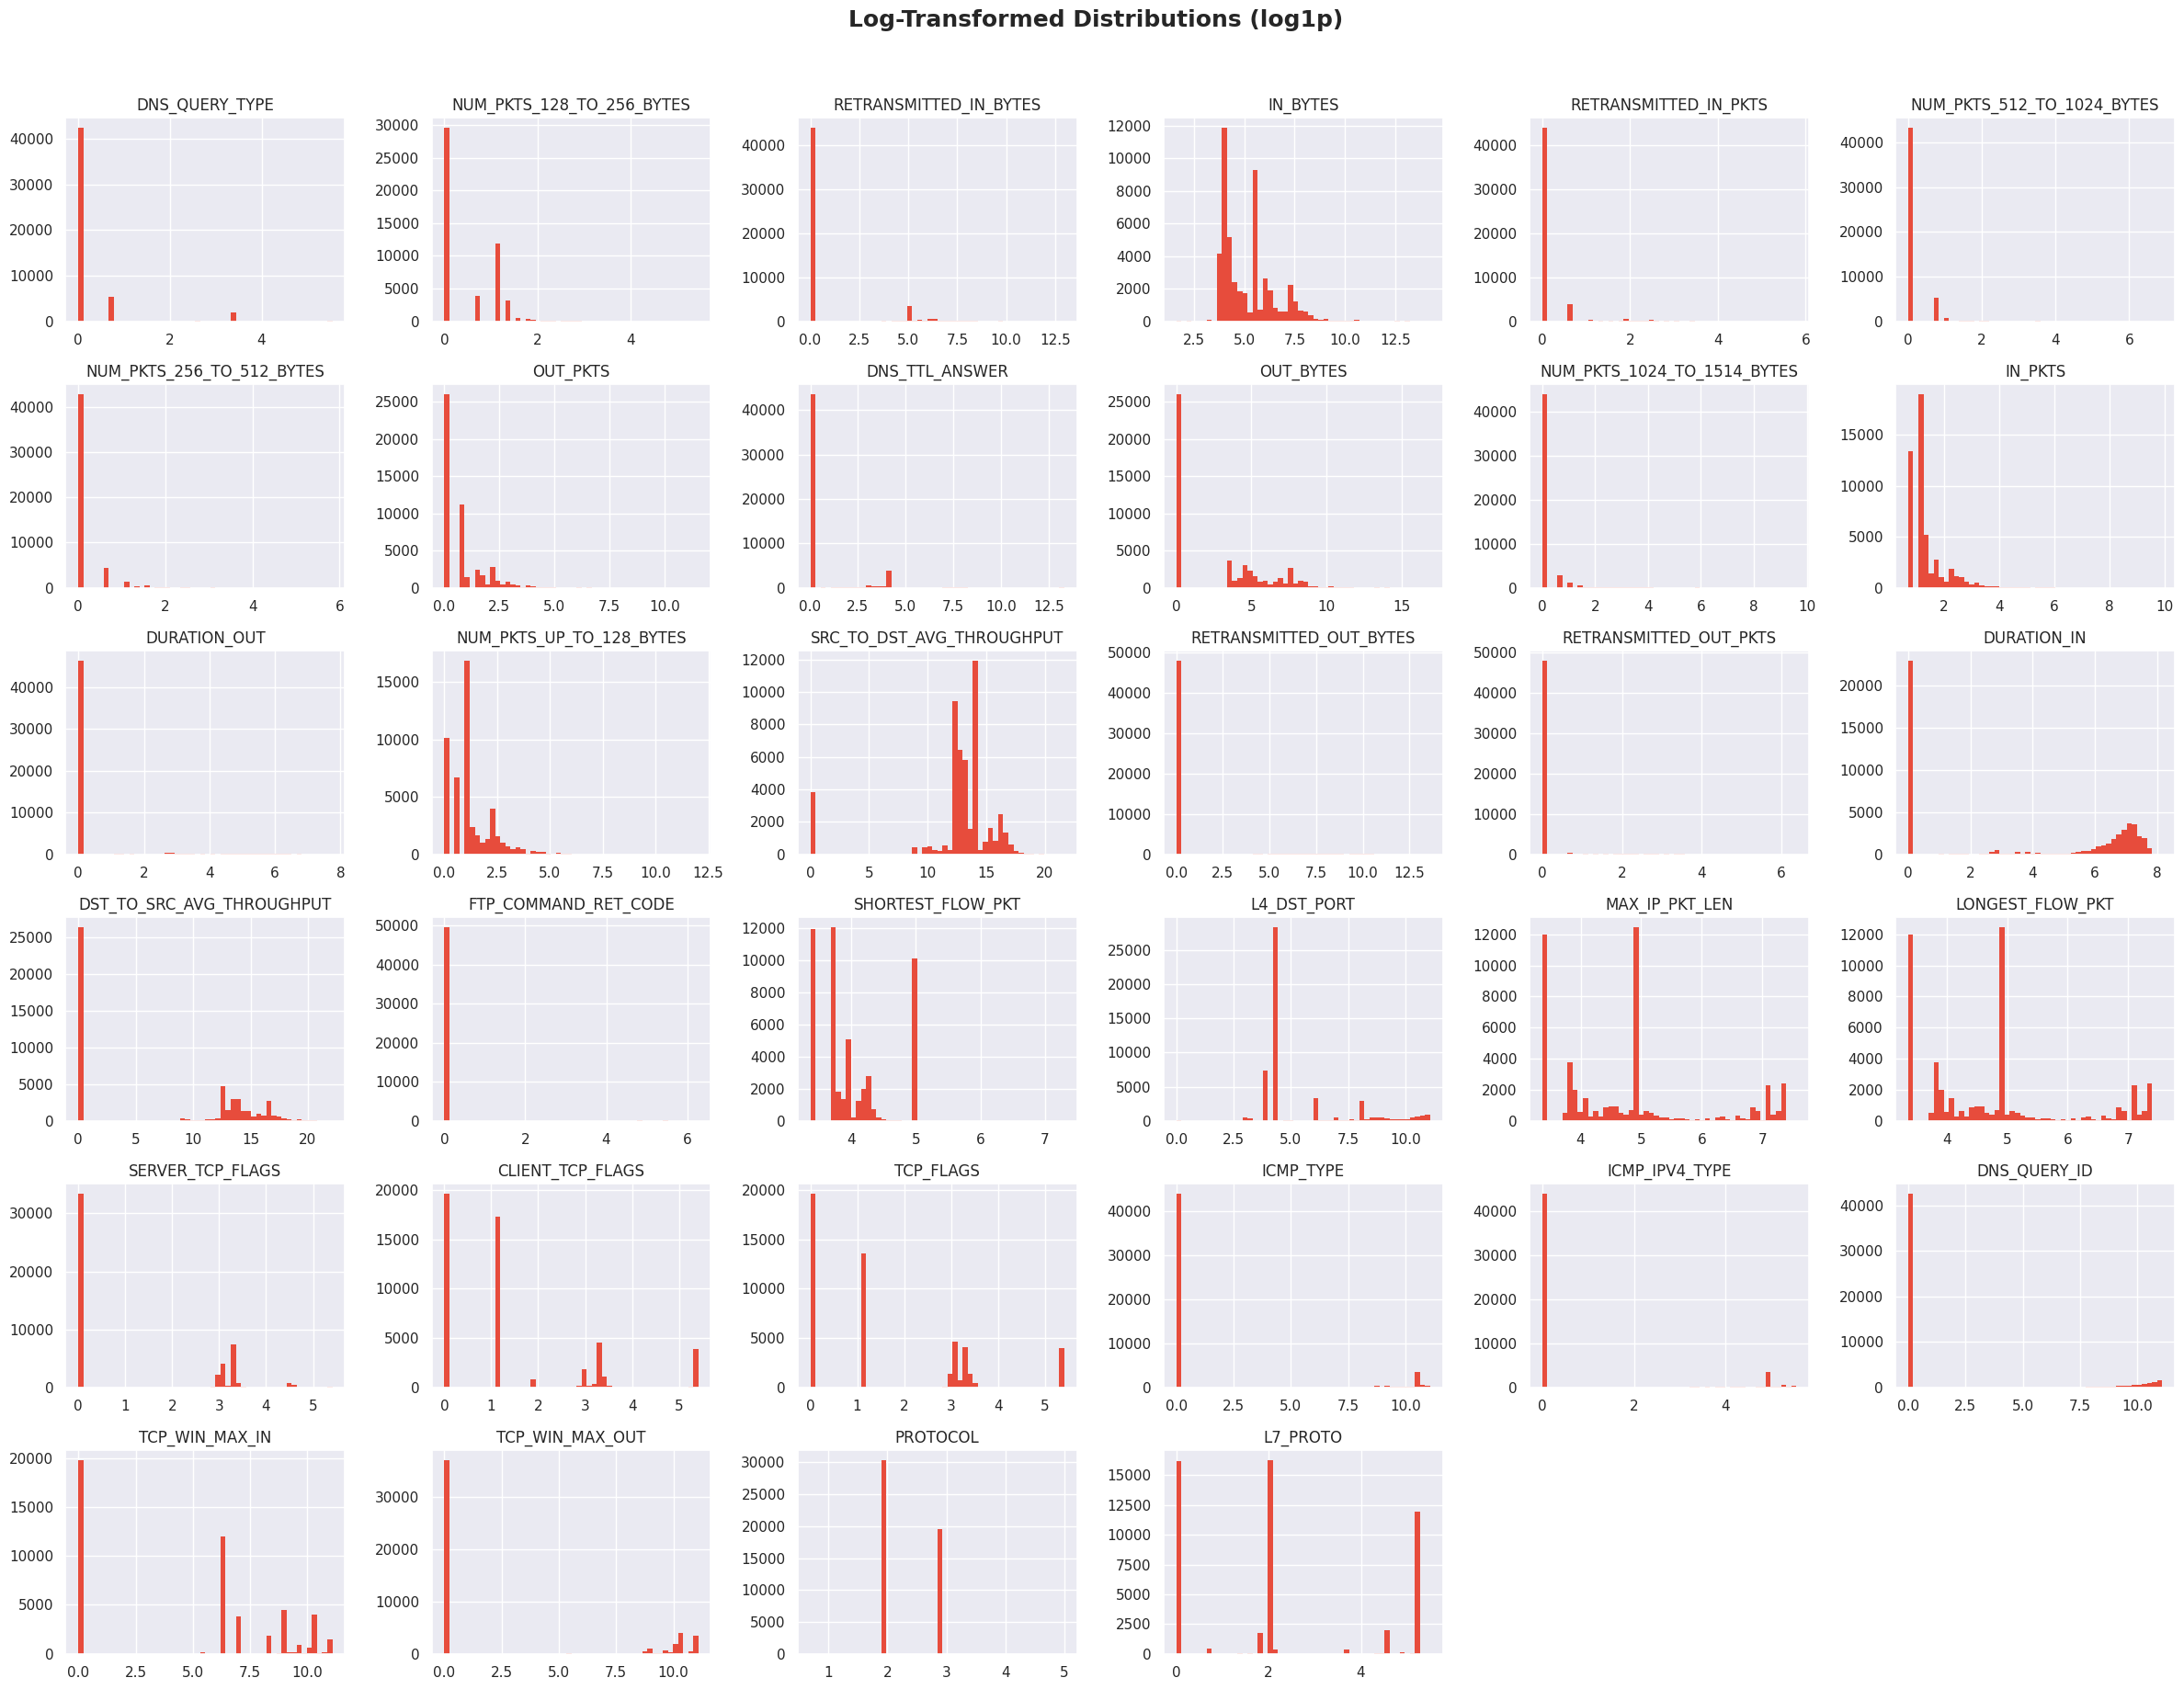

In [59]:
# Create log1p versions
log_cols = skew_kurt[skew_kurt['Needs Log Transform']].index
n_cols_log = 6
n_rows_log = int(np.ceil(len(log_cols) / n_cols_log))
log_df = np.log1p(plot_df[log_cols])
log_df.hist(bins=50, figsize=(n_cols_log * 4, n_rows_log * 3), color='#e74c3c', edgecolor='none')
plt.suptitle('Log-Transformed Distributions (log1p)', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{plots_dir}/(log1p)features_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


## Correlation Matrix

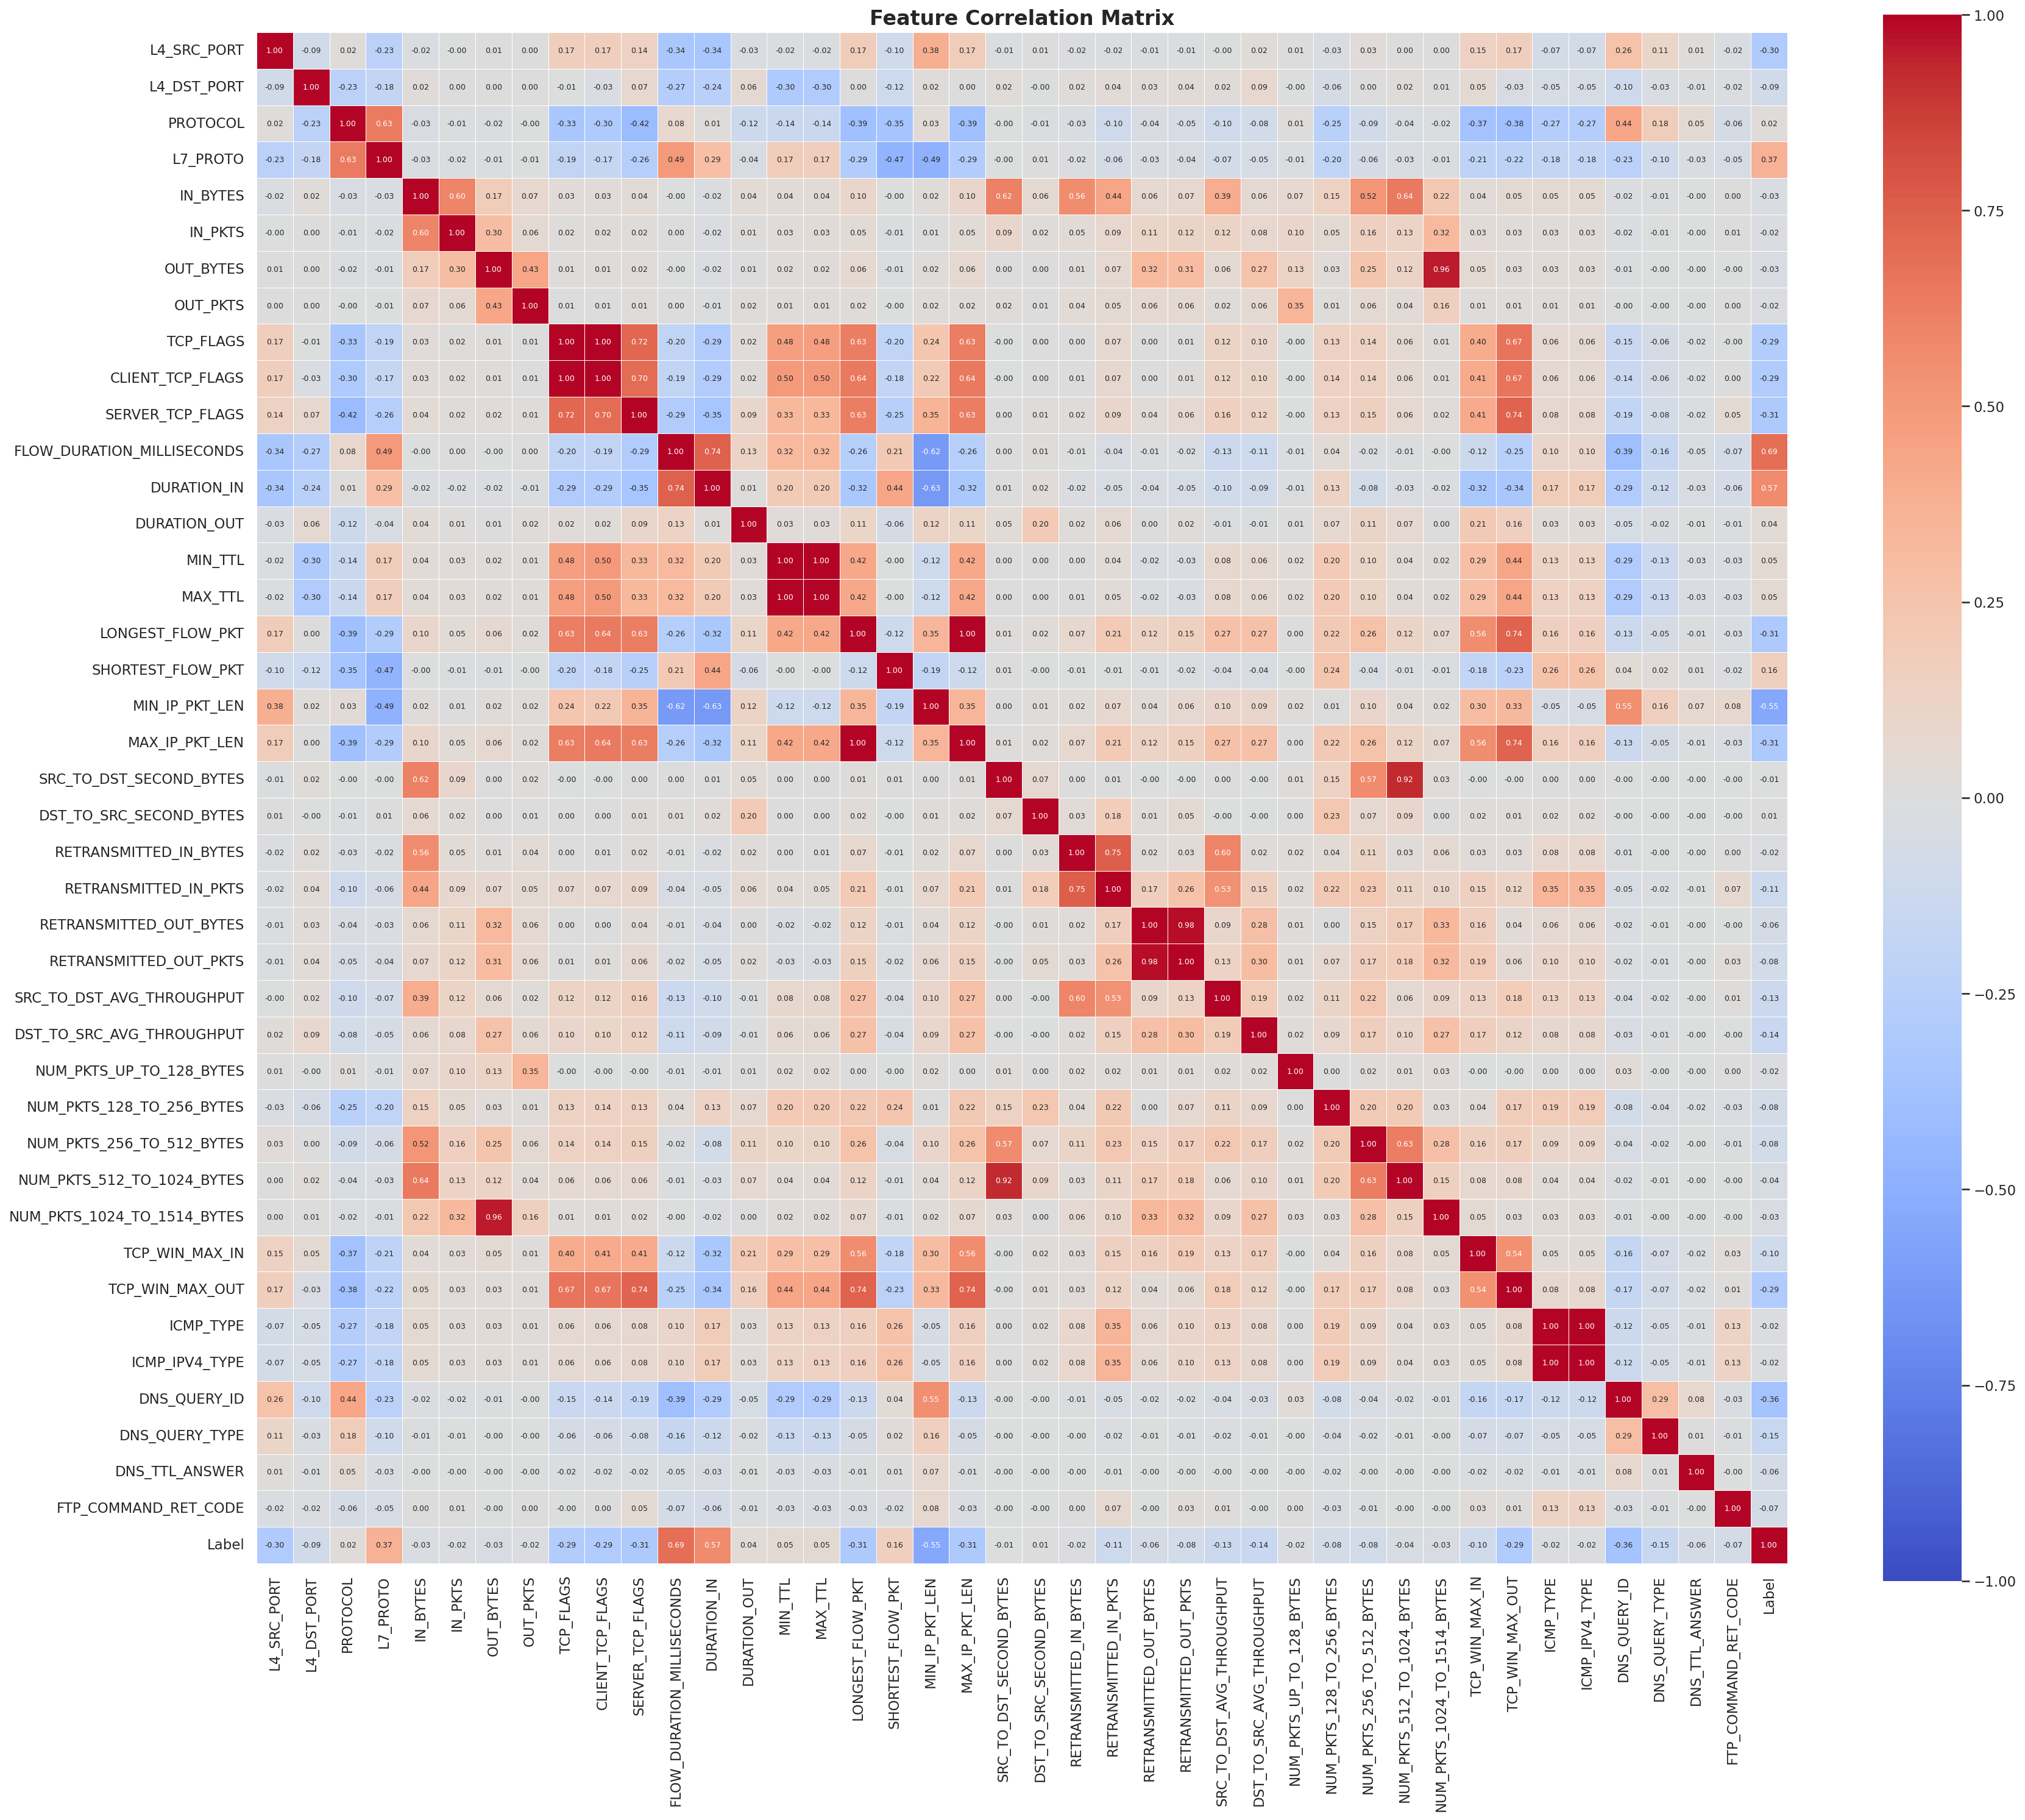

In [60]:
 corr_matrix = df[list(numerical_cols) + [binary_target]].sample(
    n=50_000, random_state=random_seed
).corr()

fig, ax = plt.subplots(figsize=(24, 20), dpi=150) # Increased size slightly so label text fits
sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.3,
    annot=True,         
    fmt='.2f',        
    annot_kws={"size": 6},
    ax=ax
)
ax.set_title('Feature Correlation Matrix', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{plots_dir}/correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


## Check For Multicollinearity
# dropping the lowest correleted pair with the target

In [61]:
# find pairs with correlation > 0.95 — candidate for removal
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)
high_corr = (
    upper.stack()
    .reset_index()
    .rename(columns={'level_0':'Feature A','level_1':'Feature B', 0:'Correlation'})
    .query('Correlation.abs() > 0.95')
)

high_corr = high_corr[
    (high_corr['Feature A'] != binary_target) & 
    (high_corr['Feature B'] != binary_target)
].sort_values('Correlation', ascending=False)

print(f"Highly correlated pairs (>0.95) excluding label: {len(high_corr)}")
print(high_corr.to_string(index=False))


Highly correlated pairs (>0.95) excluding label: 6
              Feature A                   Feature B  Correlation
       LONGEST_FLOW_PKT              MAX_IP_PKT_LEN     1.000000
              ICMP_TYPE              ICMP_IPV4_TYPE     1.000000
                MIN_TTL                     MAX_TTL     0.999494
              TCP_FLAGS            CLIENT_TCP_FLAGS     0.995533
RETRANSMITTED_OUT_BYTES      RETRANSMITTED_OUT_PKTS     0.983480
              OUT_BYTES NUM_PKTS_1024_TO_1514_BYTES     0.956922


In [62]:
target_corr = corr_matrix[binary_target].abs()
to_drop = set()

# Identify weak features from highly correlated pairs with the target
for _, row in high_corr.iterrows():
    feat_a = row['Feature A']
    feat_b = row['Feature B']
    
    if feat_a in to_drop or feat_b in to_drop:
        continue
        
    if target_corr[feat_a] >= target_corr[feat_b]:
        to_drop.add(feat_b)
    else:
        to_drop.add(feat_a)

to_drop = list(to_drop)
drop_summary = pd.DataFrame({
    'Feature to Drop': to_drop,
    'Correlation with Target': [target_corr[f] for f in to_drop]
}).sort_values(by='Correlation with Target', ascending=False)

print(f"Total features flagged for removal: {len(to_drop)}\n")
print(drop_summary.to_string(index=False))


Total features flagged for removal: 6

            Feature to Drop  Correlation with Target
             MAX_IP_PKT_LEN                 0.305258
                  TCP_FLAGS                 0.288482
    RETRANSMITTED_OUT_BYTES                 0.060985
                    MAX_TTL                 0.052493
NUM_PKTS_1024_TO_1514_BYTES                 0.032552
                  ICMP_TYPE                 0.017558


## Mutual Information (Feature Importance)
# how much does each feature tell us about the attack label

                    Feature  MI Score
           LONGEST_FLOW_PKT  0.464151
             MAX_IP_PKT_LEN  0.463813
                   IN_BYTES  0.435950
  SRC_TO_DST_AVG_THROUGHPUT  0.432863
                    MIN_TTL  0.401014
                    MAX_TTL  0.400639
                L4_DST_PORT  0.370081
                  OUT_BYTES  0.358630
  DST_TO_SRC_AVG_THROUGHPUT  0.347914
                   L7_PROTO  0.345010
          SHORTEST_FLOW_PKT  0.342616
 FLOW_DURATION_MILLISECONDS  0.302215
                DURATION_IN  0.299427
             TCP_WIN_MAX_IN  0.285931
    DST_TO_SRC_SECOND_BYTES  0.254954
                    IN_PKTS  0.226240
             MIN_IP_PKT_LEN  0.203360
   NUM_PKTS_UP_TO_128_BYTES  0.195257
                   OUT_PKTS  0.185998
            TCP_WIN_MAX_OUT  0.161025
                L4_SRC_PORT  0.141462
             DNS_TTL_ANSWER  0.130009
                  TCP_FLAGS  0.110047
           SERVER_TCP_FLAGS  0.103825
           CLIENT_TCP_FLAGS  0.096150
            

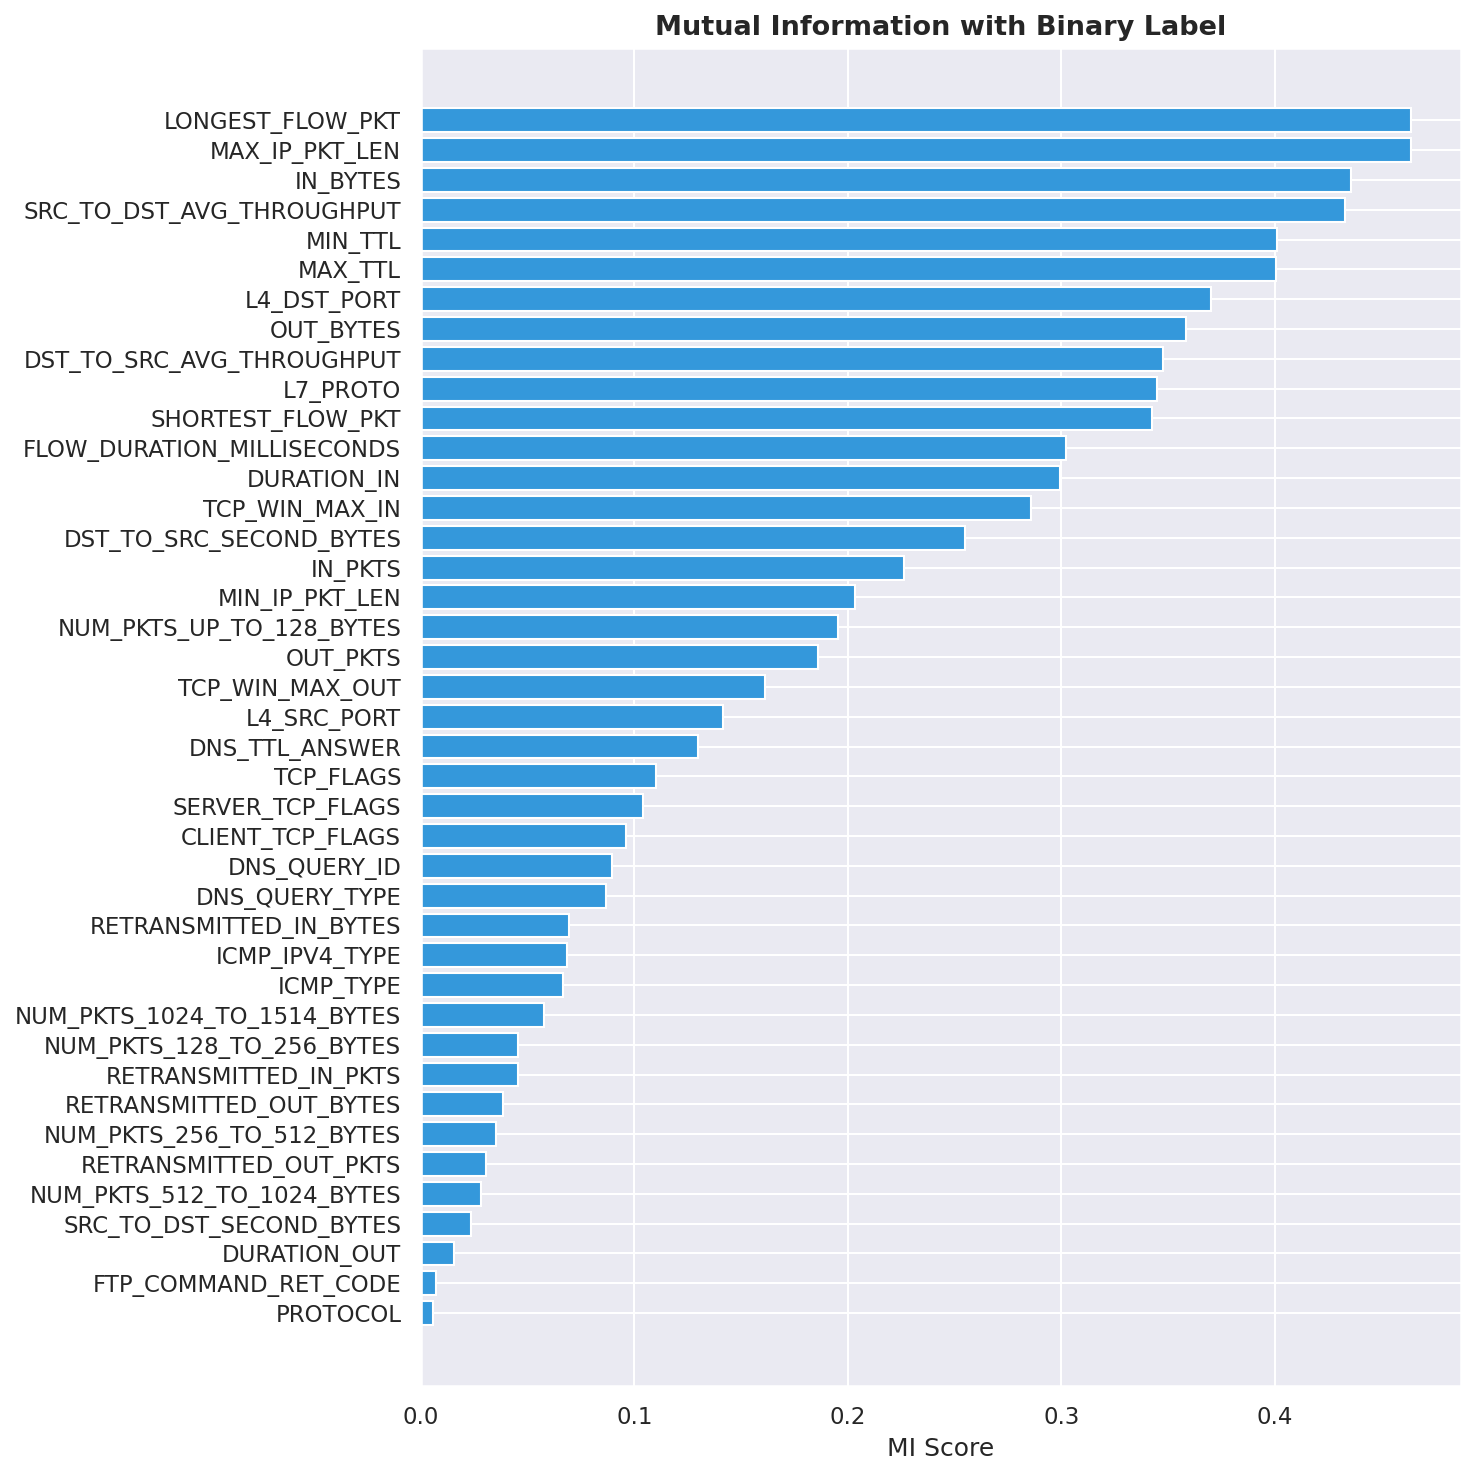

In [63]:
mi_sample = df[numerical_cols + [binary_target]].sample(
    n=100_000, random_state=random_seed
).dropna()

mi_scores = mutual_info_classif(
    mi_sample[numerical_cols],
    mi_sample[binary_target],
    random_state=random_seed
)

mi_df = pd.DataFrame({
    'Feature' : numerical_cols,
    'MI Score': mi_scores
}).sort_values('MI Score', ascending=False)

print(mi_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 10), dpi=150)
ax.barh(mi_df['Feature'], mi_df['MI Score'],
        color='#3498db', edgecolor='white')
ax.set_title('Mutual Information with Binary Label',
             fontsize=13, fontweight='bold')
ax.set_xlabel('MI Score')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(f'{plots_dir}/mutual_information.png', dpi=150, bbox_inches='tight')
plt.show()

## Feature Distributions by Attack Type

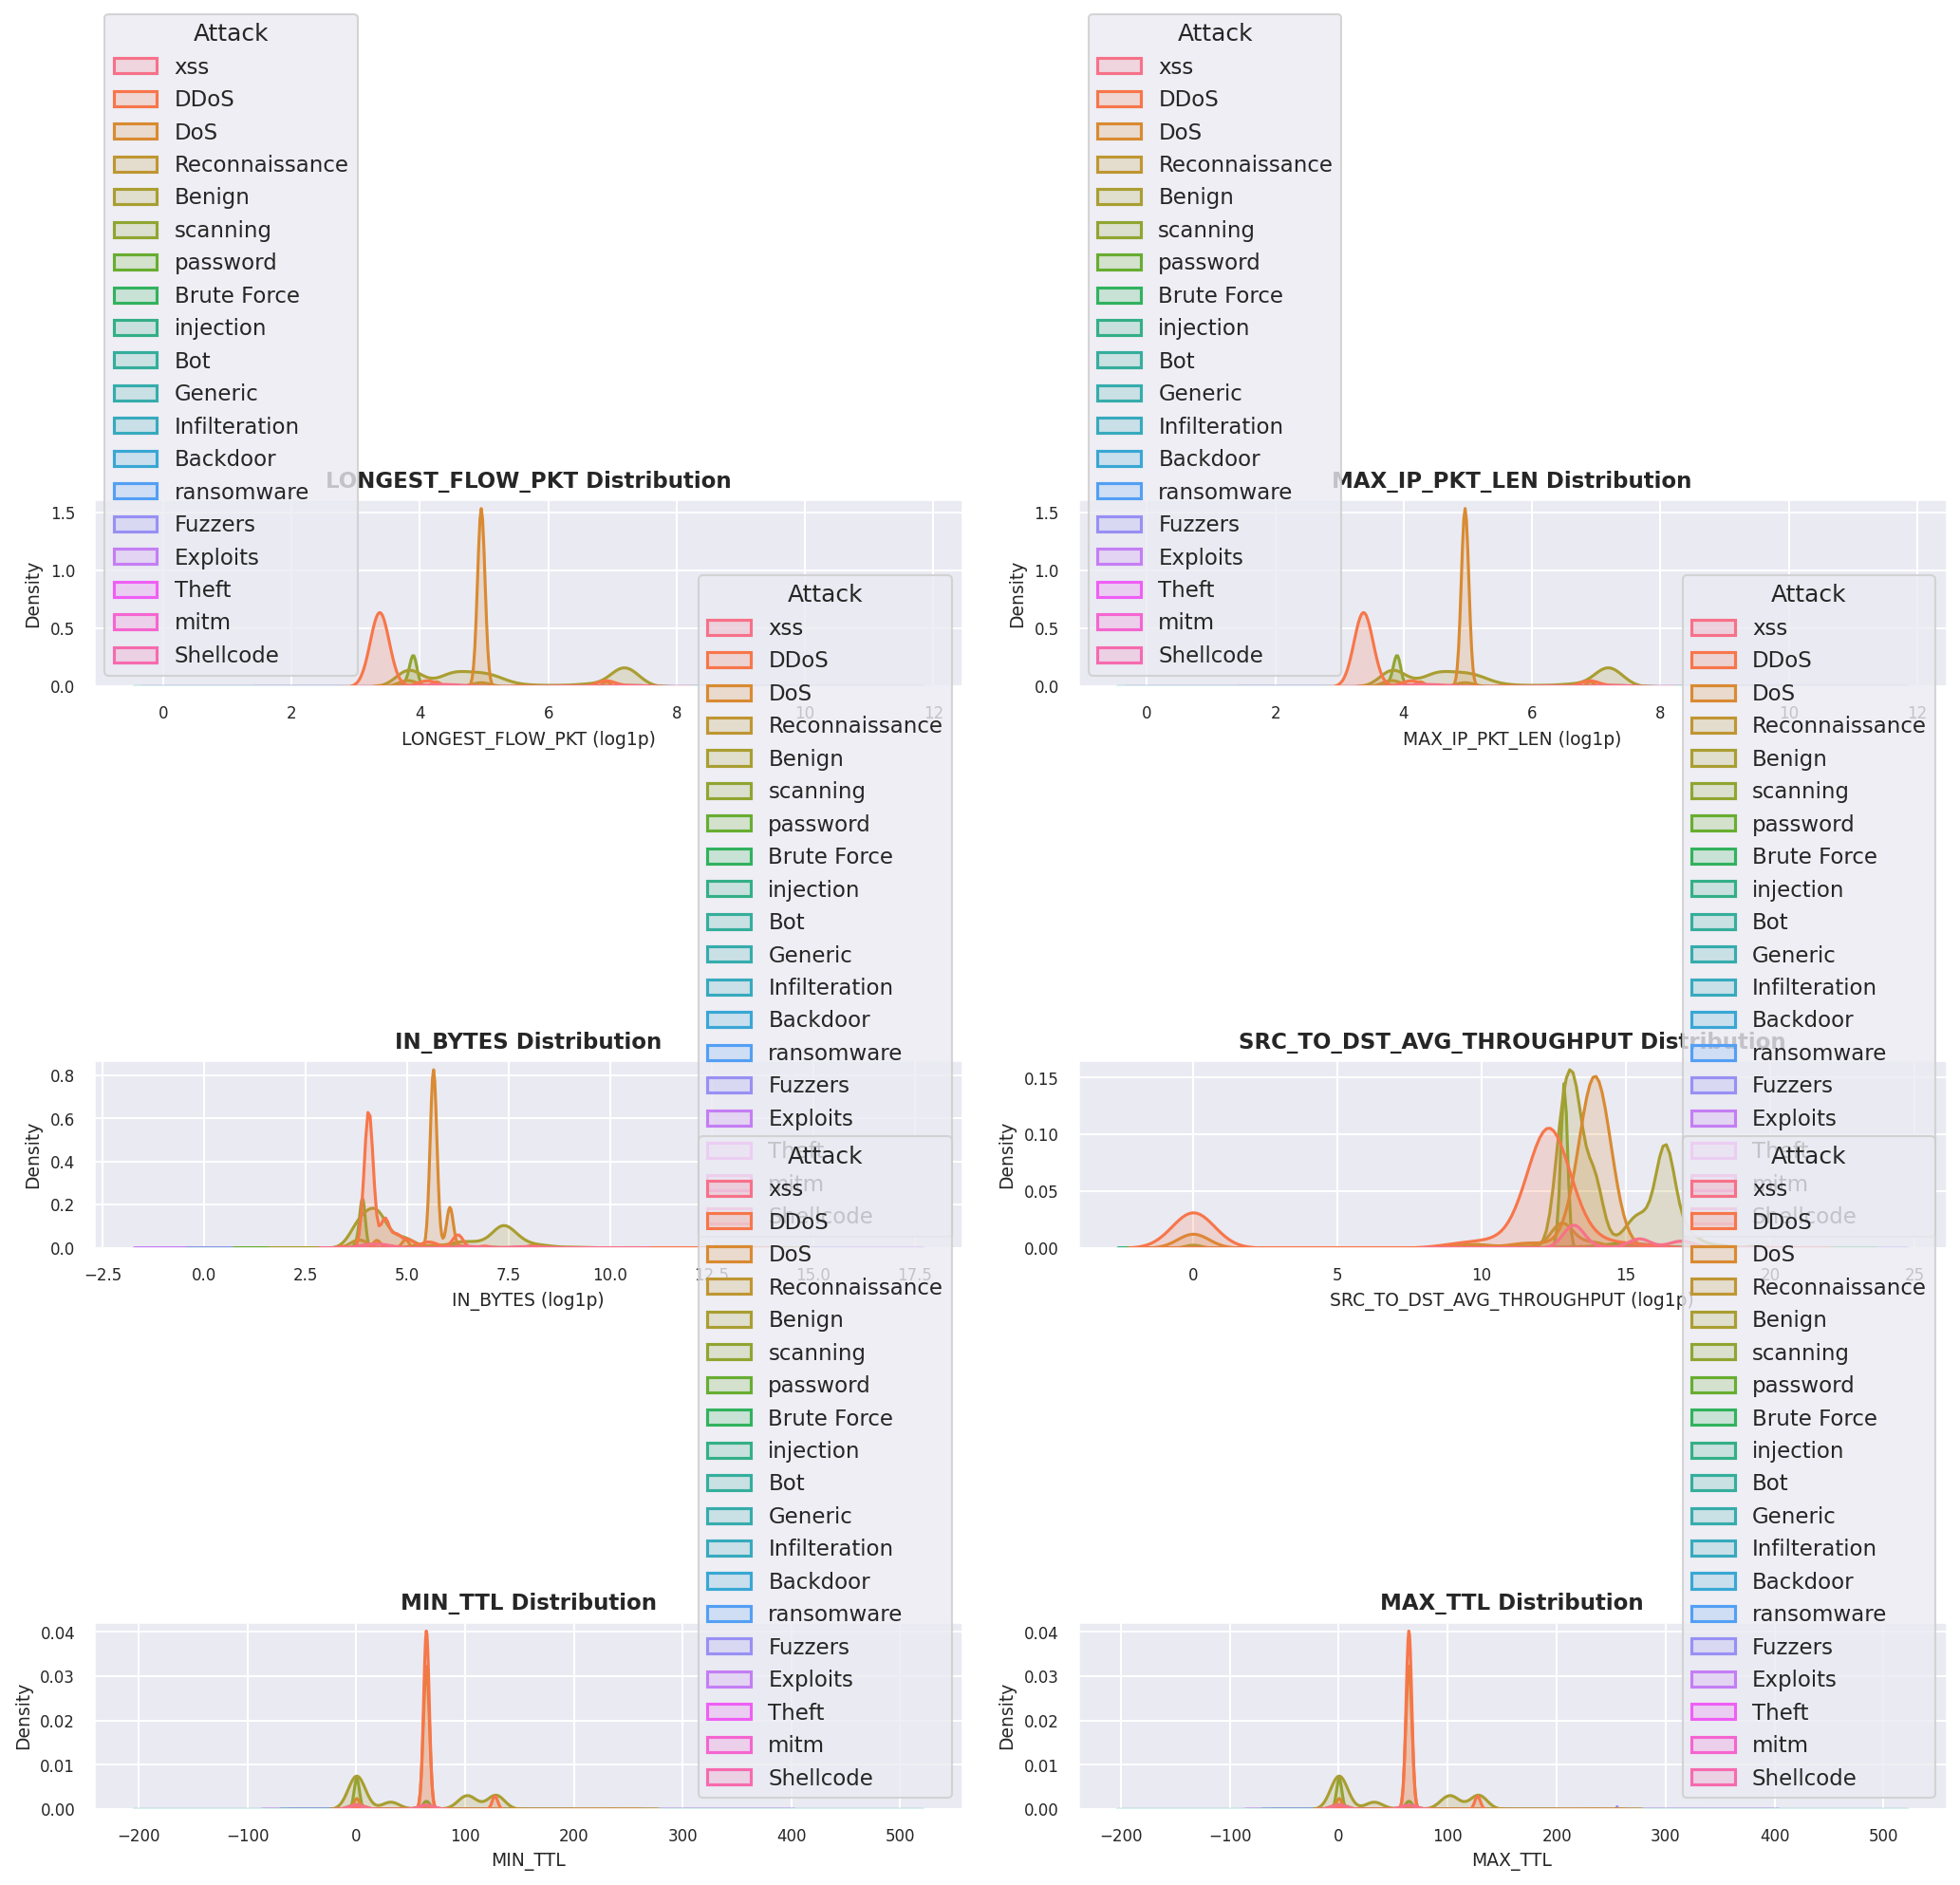

In [64]:
#Extracted top 6 features from your MI rankings
top_mi_features = [
    'LONGEST_FLOW_PKT', 
    'MAX_IP_PKT_LEN', 
    'IN_BYTES', 
    'SRC_TO_DST_AVG_THROUGHPUT', 
    'MIN_TTL', 
    'MAX_TTL'
]
attack_type_col = multi_class_target 


plot_df = df[top_mi_features + [attack_type_col]].sample(n=50_000, random_state=random_seed)


n_cols = 2
n_rows = 3
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 7, n_rows * 4), dpi=150)
axes = axes.flatten()

# 4. Loop and plot distributions
for i, col in enumerate(top_mi_features):
    clean_data = plot_df[[col, attack_type_col]].dropna()
    if clean_data[col].skew() > 1 and clean_data[col].min() >= 0:
        clean_data[col] = np.log1p(clean_data[col])
        xlabel = f'{col} (log1p)'
    else:
        xlabel = col
    # Grouped Kernel Density Estimate (KDE) plot
    sns.kdeplot(
        data=clean_data, 
        x=col, 
        hue=attack_type_col, 
        fill=True, 
        alpha=0.2, 
        linewidth=1.5,
        ax=axes[i]
    )
    axes[i].set_title(f'{col} Distribution', fontsize=11, fontweight='bold')
    axes[i].set_xlabel(xlabel, fontsize=9)
    axes[i].set_ylabel('Density', fontsize=9)
    axes[i].tick_params(labelsize=8)

plt.tight_layout()
plt.savefig(f'{plots_dir}/top_mi_features_by_attack.png', dpi=150, bbox_inches='tight')
plt.show()


## PCA — Benign vs Attack Separability
PCA explained only 27.26% of variance in 2 components, confirming the dataset 
has high intrinsic dimensionality and non-linear structure that linear projections 
cannot capture. This motivates the selection of tree-based (XGBoost, CatBoost) and 
attention-based (TabNet, FT-Transformer) models over linear classifiers, and the 
use of RobustScaler to handle the skewed non-linear feature distributions confirmed 
by this analysis.

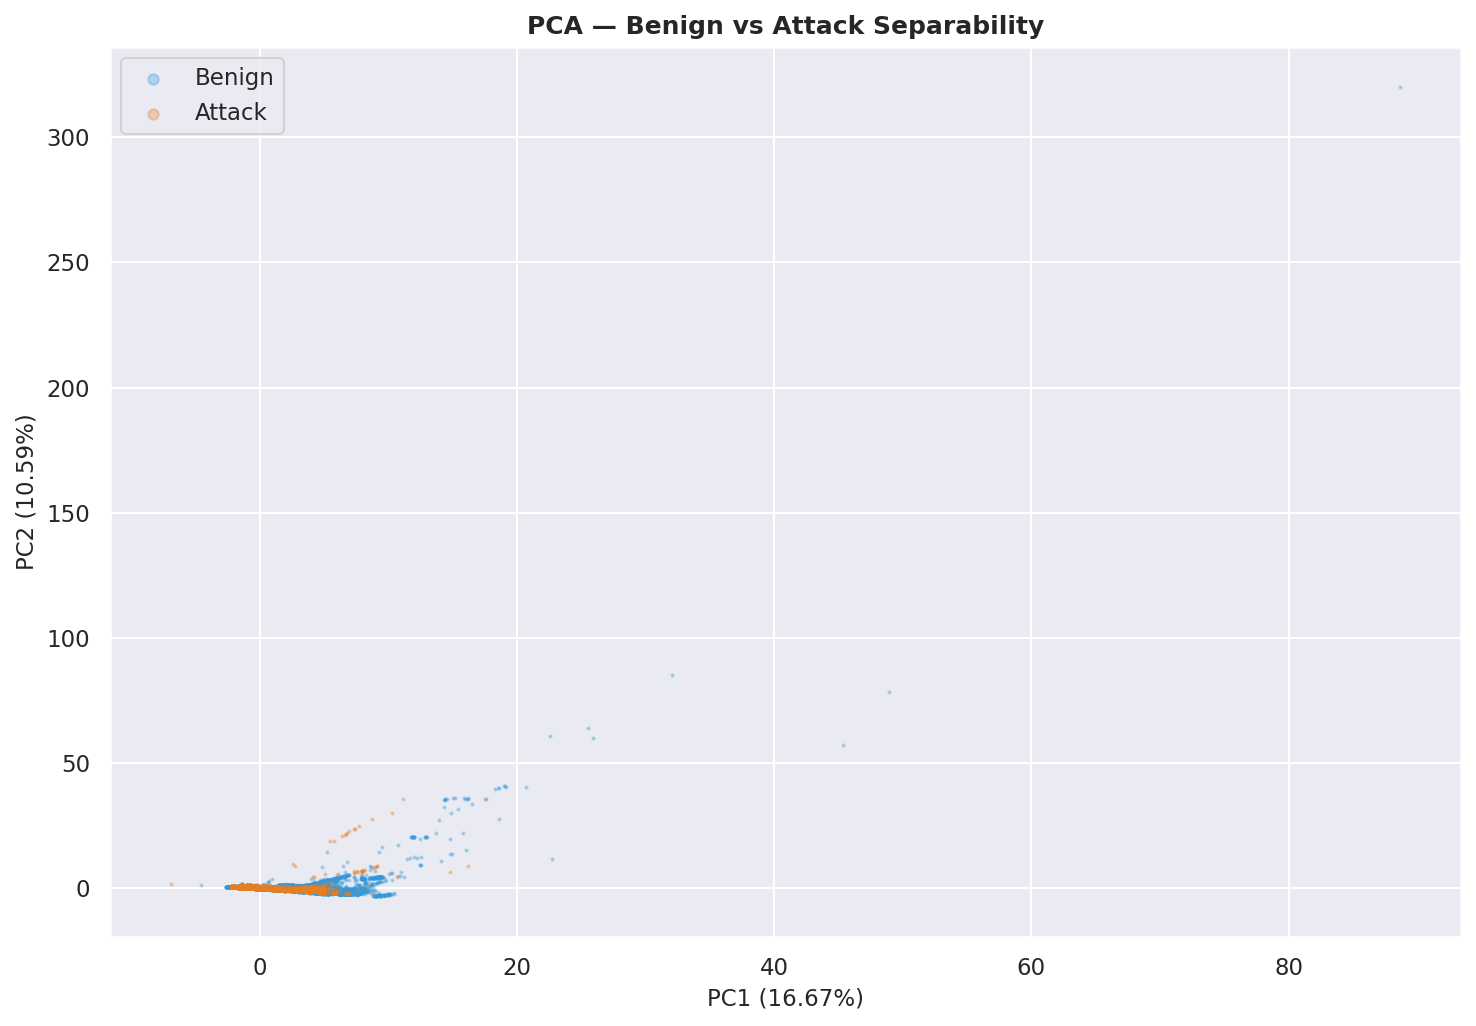

PC1 explained variance : 16.67%
PC2 explained variance : 10.59%
Total                  : 27.26%


In [65]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

pca_sample = df[numerical_cols + [binary_target]].dropna().sample(
    n=50_000, random_state=random_seed
)
X_scaled   = StandardScaler().fit_transform(pca_sample[numerical_cols])
pca        = PCA(n_components=2, random_state=random_seed)
components = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(10, 7), dpi=150)
for label, color, name in zip([0,1], ['#3498db','#e67e22'], ['Benign','Attack']):
    mask = pca_sample[binary_target].values == label
    ax.scatter(components[mask,0], components[mask,1],
               c=color, label=name, alpha=0.3, s=1)
ax.set_title('PCA — Benign vs Attack Separability', fontweight='bold')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)', fontsize=11) 
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)', fontsize=11)  
ax.legend(markerscale=5)
plt.tight_layout()
plt.savefig(f'{plots_dir}/pca.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"PC1 explained variance : {pca.explained_variance_ratio_[0]*100:.2f}%")
print(f"PC2 explained variance : {pca.explained_variance_ratio_[1]*100:.2f}%")
print(f"Total                  : {pca.explained_variance_ratio_.sum()*100:.2f}%")

## Saving The Artefacts 

In [66]:
from IPython.display import FileLink
import shutil
source_dir = '/kaggle/working/plots_eda'
zip_filename = 'eda_plots_final_output.zip'
if os.path.exists(source_dir):
    shutil.make_archive(zip_filename.replace('.zip', ''), 'zip', source_dir)
    print(f"{source_dir}!")
    display(FileLink(zip_filename))
else:
    print(f"'{source_dir}' directory not found")


/kaggle/working/plots_eda!


/kaggle/working/eda_plots_final_output.zip